## AFM groove fits per measurement directory

Loads AFM `.txt` files from each measurement directory, runs the LMI_util processing pipeline, and plots every detected groove together with its trapezoidal fit. After the plots, the bottom of the notebook ranks all grooves across every directory by RMSE and by `|TLW - BLW|` to surface the cleanest fits and the most-square gratings.

In [50]:
%load_ext autoreload
%autoreload 2

import sys, os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Add repo root so we can import LMI_util
REPO_ROOT = Path(os.getcwd()).resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT))

from LMI_util.AFM_analysis import (
    load_all_AFM,
    process_data,
)

AFM_ROOT = REPO_ROOT / 'experimental_data' / 'AFM'

# Default processing params (tweak per directory if a fit looks bad)
DEFAULT_PROC = dict(
    baseline_lvl=30,
    min_segment_length=30,
    interp_points=5,
    window_size_base=5,
    blw_lvl_base=0.1,
    tlw_lvl_base=0.9,
)

ALL_RECORDS = []  # collect every processed record across every directory for the ranking section

def process_directory(rel_path, sample_name, proc_overrides=None):
    """Load + process every .txt in a measurement dir, append to ALL_RECORDS, return the list."""
    proc = {**DEFAULT_PROC, **(proc_overrides or {})}
    afm = load_all_AFM(AFM_ROOT / rel_path, sample_name=sample_name)
    process_data(afm, **proc)
    ALL_RECORDS.extend(afm)
    return afm

def plot_overview(record, dir_label):
    """Two-panel overview: (raw + baseline) and (raw leveled + smoothed leveled)."""
    tag = os.path.splitext(os.path.basename(record['grating']))[0]
    x = record['x dense']
    y_raw = record['y dense']
    baseline = record['baseline']
    y_raw_lvl = record['y raw level']
    y_smooth_lvl = record['y smooth level']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4), layout='constrained')

    ax1.plot(x, y_raw, color='red', lw=1, label='AFM raw')
    ax1.plot(x, baseline, color='black', lw=1.5, linestyle='--', label='baseline fit')
    ax1.set_title('Original AFM + baseline', fontsize=18)
    ax1.grid(alpha=0.3)
    ax1.legend(fontsize=8)

    ax2.plot(x, y_raw_lvl, color='red', lw=1, label='AFM leveled')
    ax2.plot(x, y_smooth_lvl, color='blue', lw=1.2, label='moving avg')
    ax2.set_title('Leveled AFM + moving average', fontsize=18)
    ax2.grid(alpha=0.3)
    ax2.legend(fontsize=8)

    fig.suptitle(f'{tag}', fontsize=20)
    fig.supxlabel('x (um)', fontsize=16)
    fig.supylabel('y (um)', fontsize=16)
    fig.tight_layout()
    plt.show()

def plot_grooves_with_fits(afm, dir_label):
    """For each record: overview (raw+baseline, leveled+smooth), then per-groove fit grid."""
    for record in afm:
        plot_overview(record, dir_label)

        grooves = record['grooves smooth']
        fits = record['groove fits']
        rmse = record['rmse']
        tag = os.path.splitext(os.path.basename(record['grating']))[0]

        n = len(grooves)
        if n == 0:
            print(f'(no grooves) {tag}')
            continue
        ncols = min(n, 4)
        nrows = (n + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), squeeze=False, layout='constrained')
        axes_flat = axes.flatten()
        for i, ((xs, ys), (xf, yf)) in enumerate(zip(grooves, fits)):
            ax = axes_flat[i]
            ax.plot(xs, ys, color='red', lw=1.2, label='AFM (smooth)')
            ax.plot(xf, yf, color='black', lw=1.5, linestyle='--', label='trap fit')
            ax.grid(alpha=0.3)
            if i == 0:
                ax.legend(fontsize=8)

        for j in range(n, len(axes_flat)):
            axes_flat[j].axis('off')
        fig.suptitle(f'{tag}  (groove fits)', fontsize=20)
        fig.supxlabel('x (um)', fontsize=16)
        fig.supylabel('y (um)', fontsize=16)
        plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## NRS06032024

data index = 0
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 4
Number of grooves (smooth) = 4
Fit Heights (um): 0.264 0.267 0.267 0.274

data index = 1
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 3
Number of grooves (smooth) = 3
Fit Heights (um): 0.357 0.361 0.36



C:\Users\robert\AppData\Local\Temp\ipykernel_15976\3324958719.py:67: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


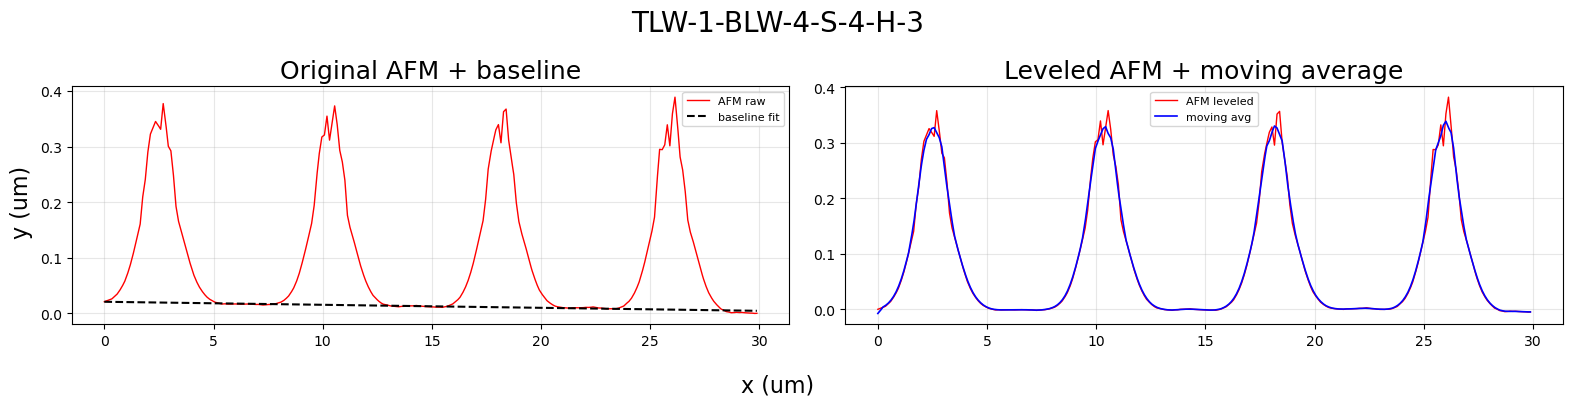

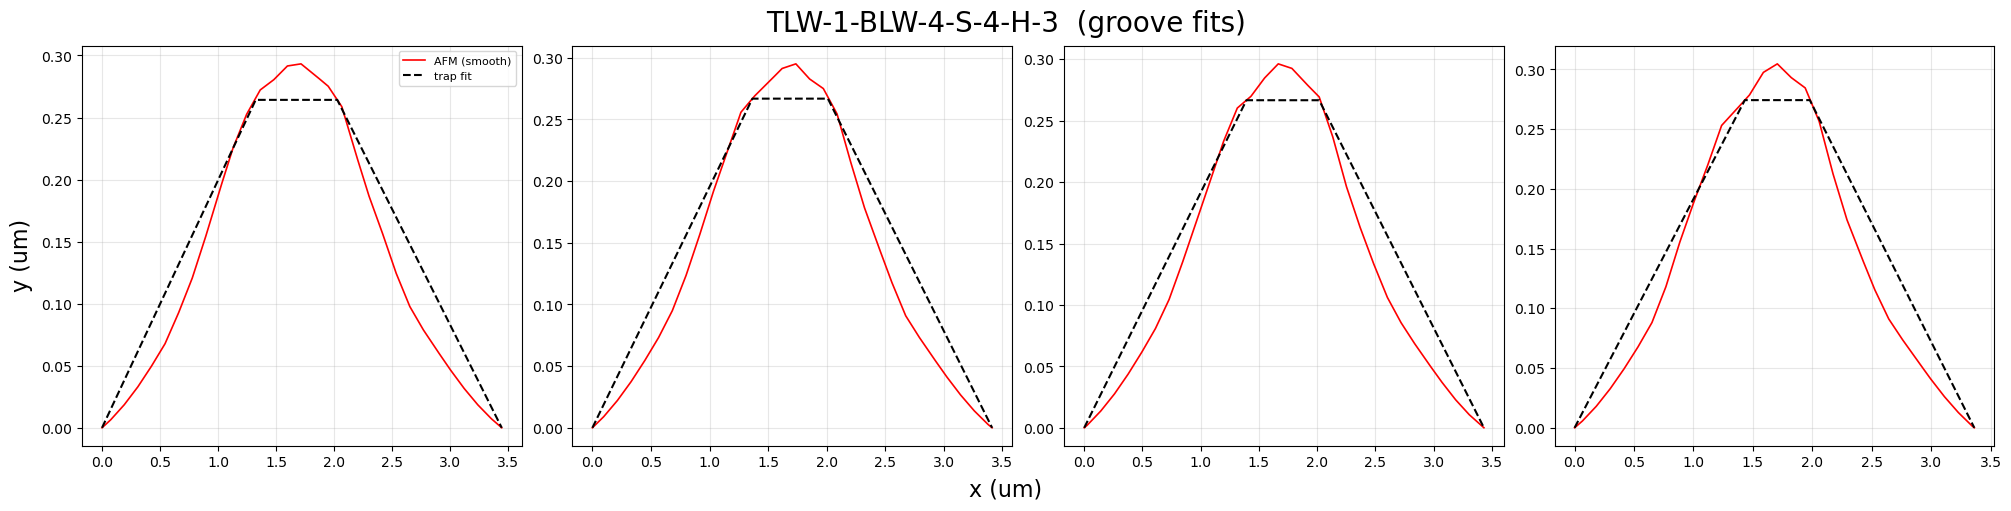

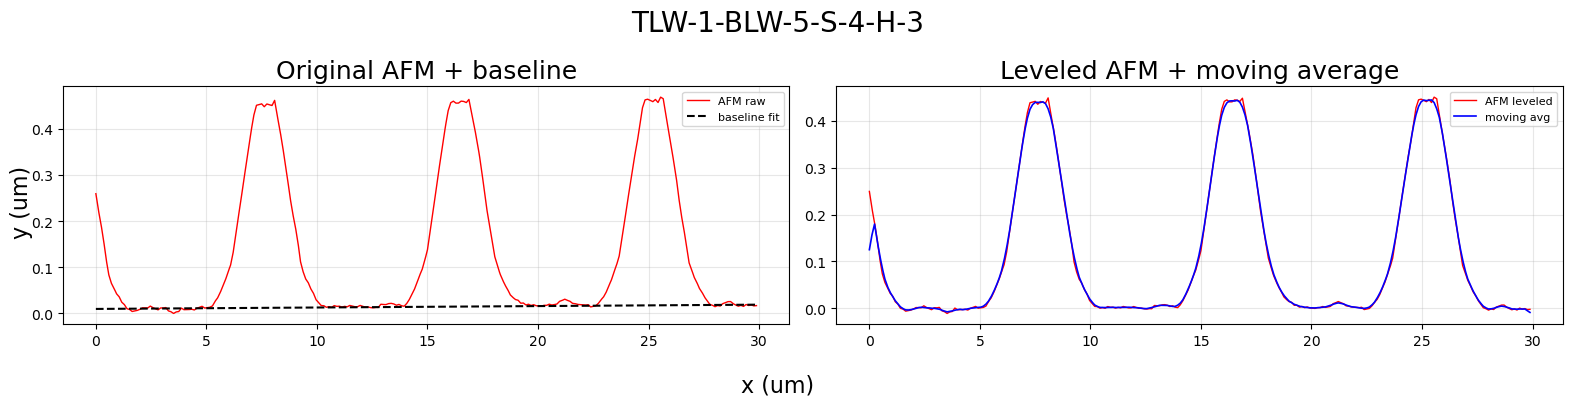

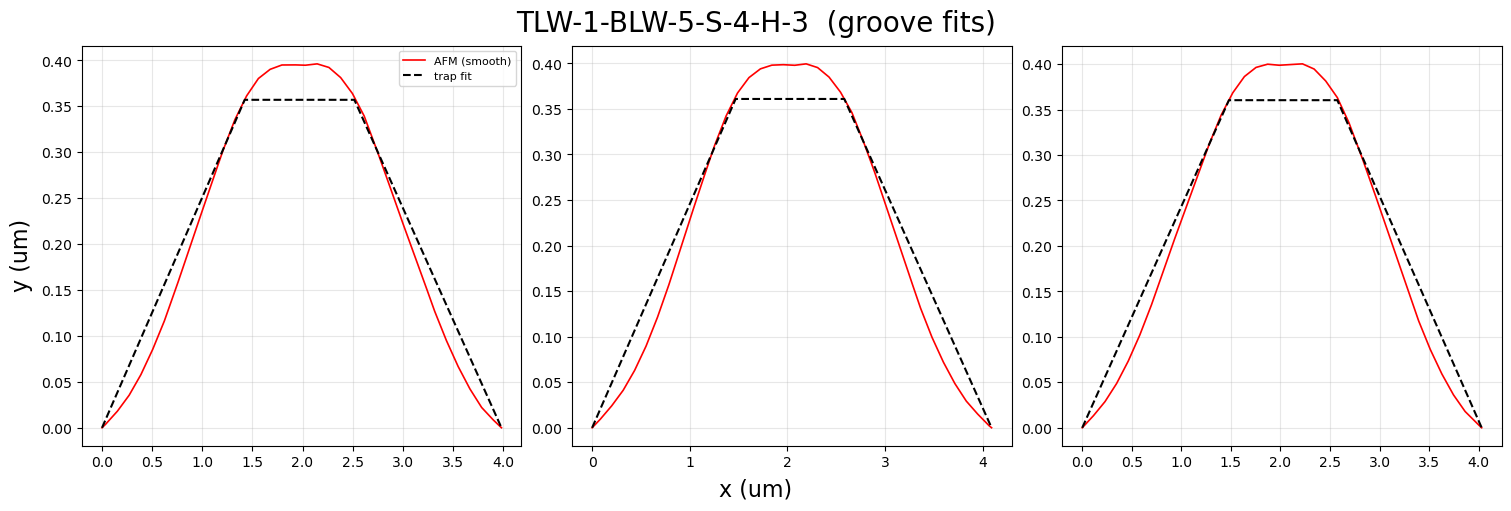

In [51]:
# NRS06032024 / NRS06032024_S-4_H-3_TLW-1_BLW-xx_AFM
REL = 'NRS06032024/NRS06032024_S-4_H-3_TLW-1_BLW-xx_AFM'
afm = process_directory(REL, sample_name='NRS06032024')
plot_grooves_with_fits(afm, REL)

data index = 0
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 4
Number of grooves (smooth) = 4
Fit Heights (um): 0.295 0.296 0.294 0.294

data index = 1
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 3
Number of grooves (smooth) = 3
Fit Heights (um): 0.406 0.403 0.418

data index = 2
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 3
Number of grooves (smooth) = 3
Fit Heights (um): 0.564 0.561 0.563

data index = 3
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 3
Number of grooves (smooth) = 3
Fit Heights (um): 0.61 0.595 0.61

data index = 4
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 3
Number of grooves (smooth) = 3
Fit Heights (um): 0.557 0.557 0.557



C:\Users\robert\AppData\Local\Temp\ipykernel_15976\3324958719.py:67: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


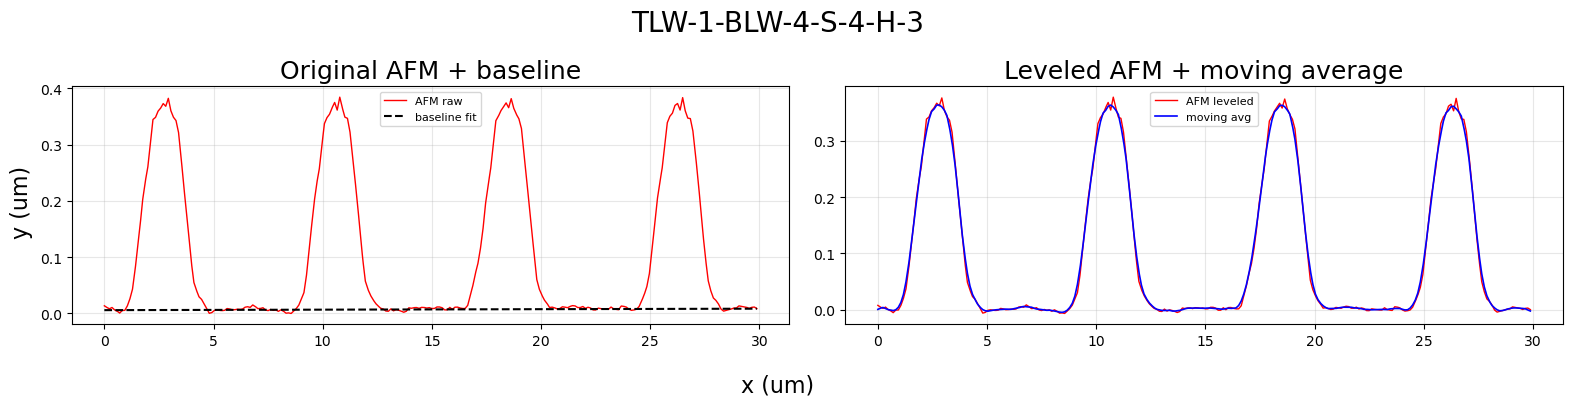

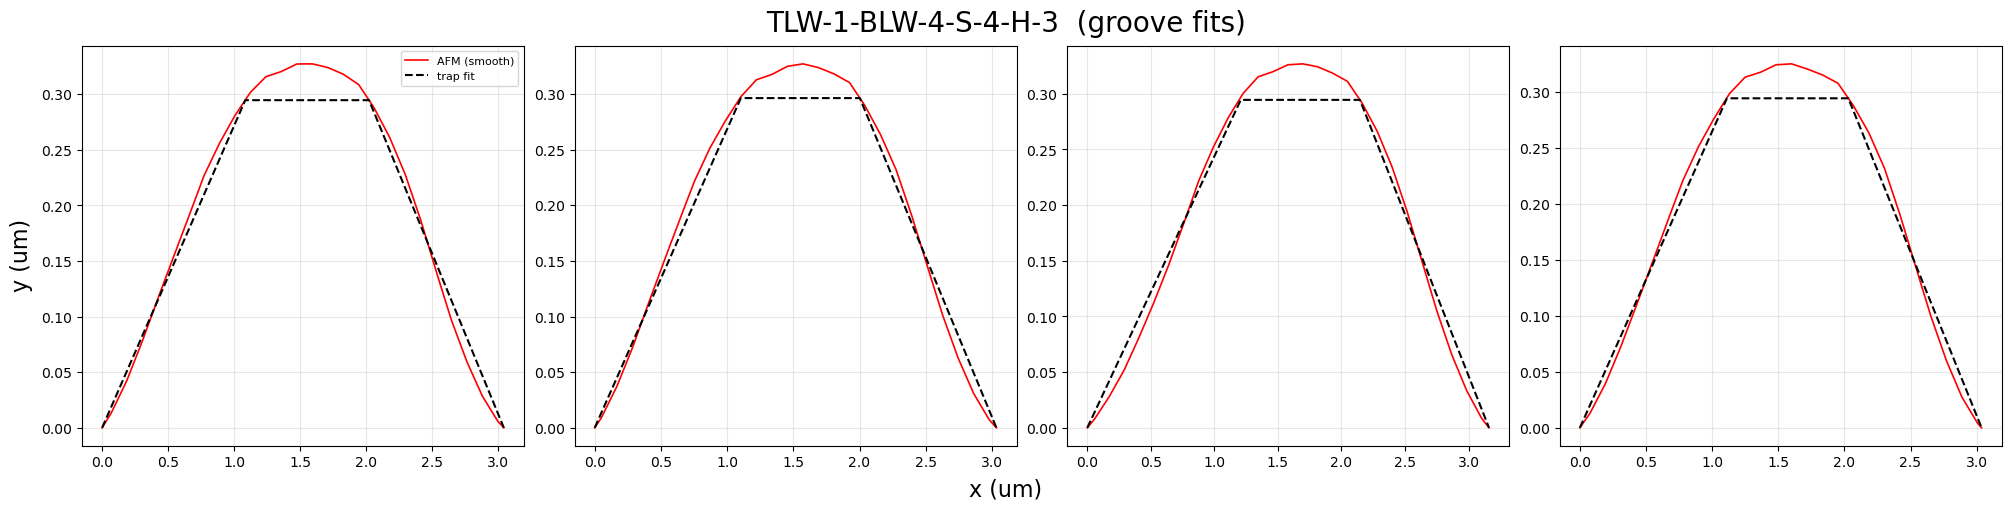

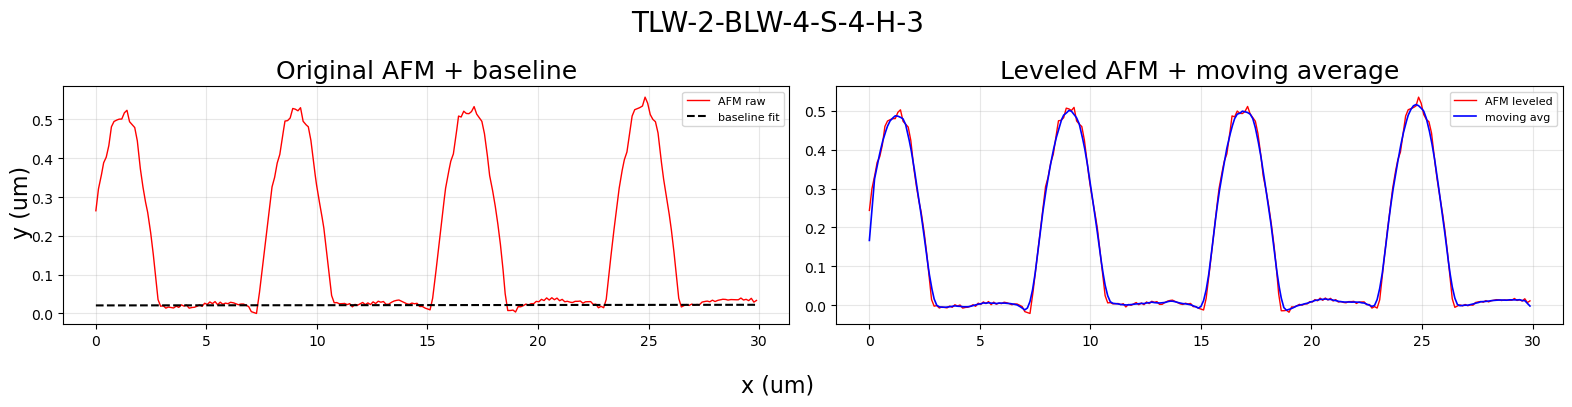

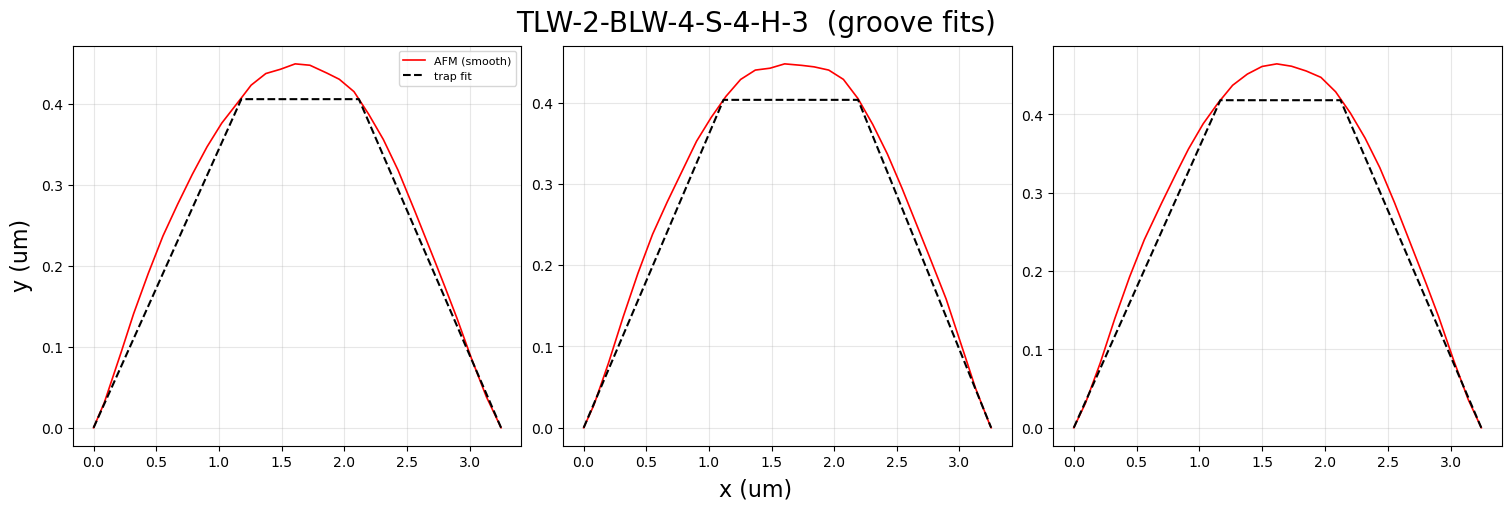

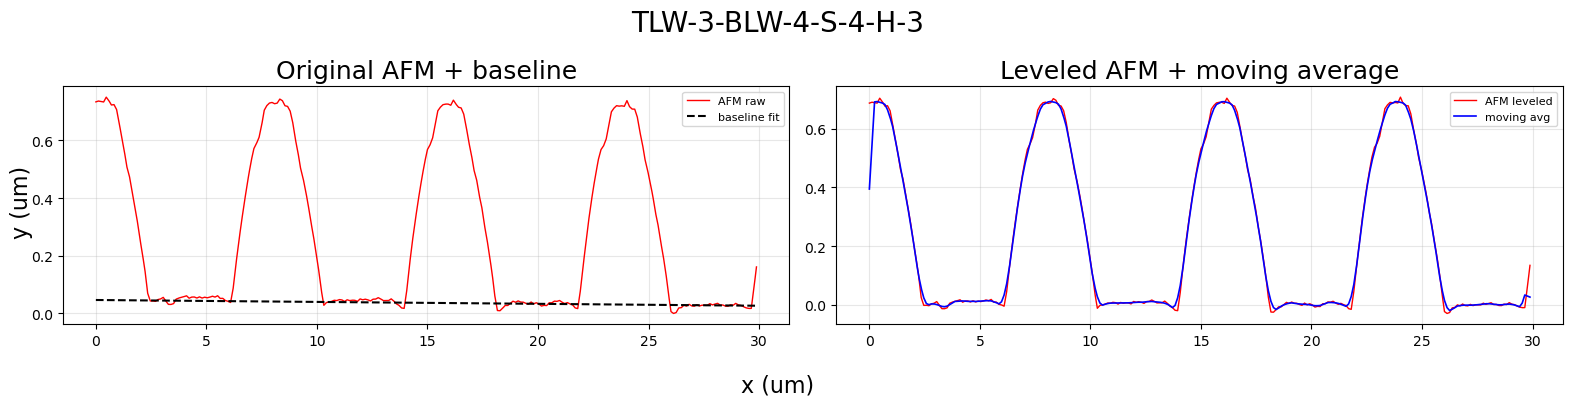

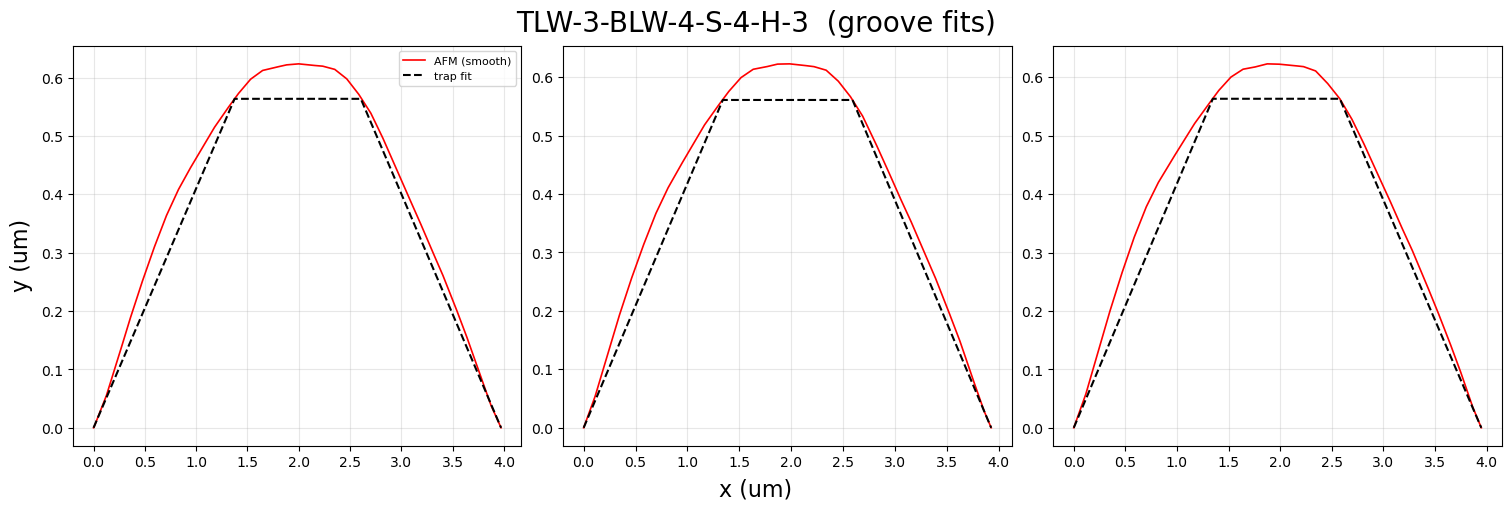

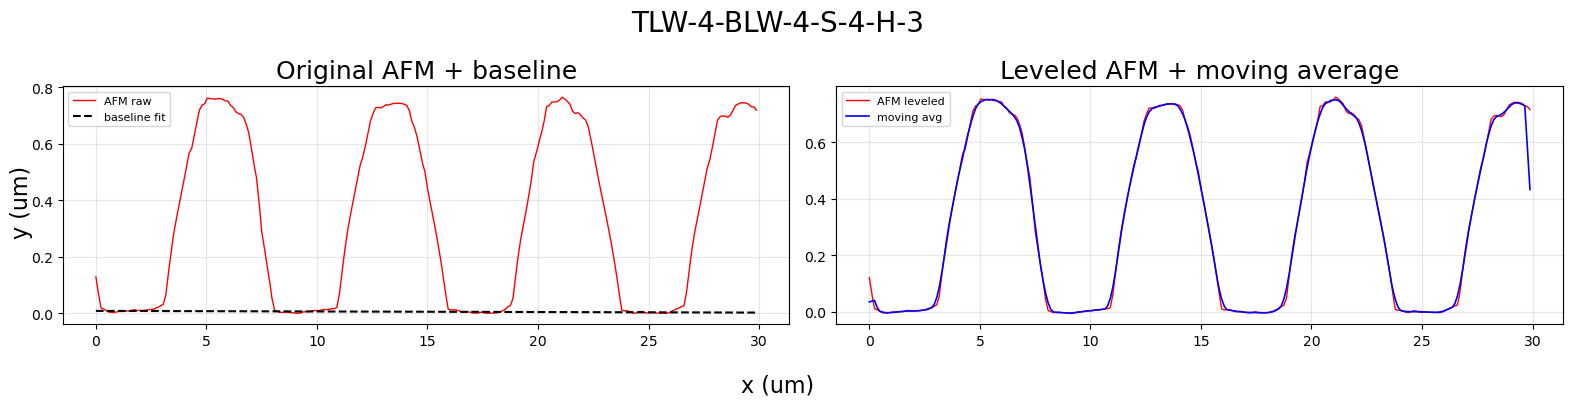

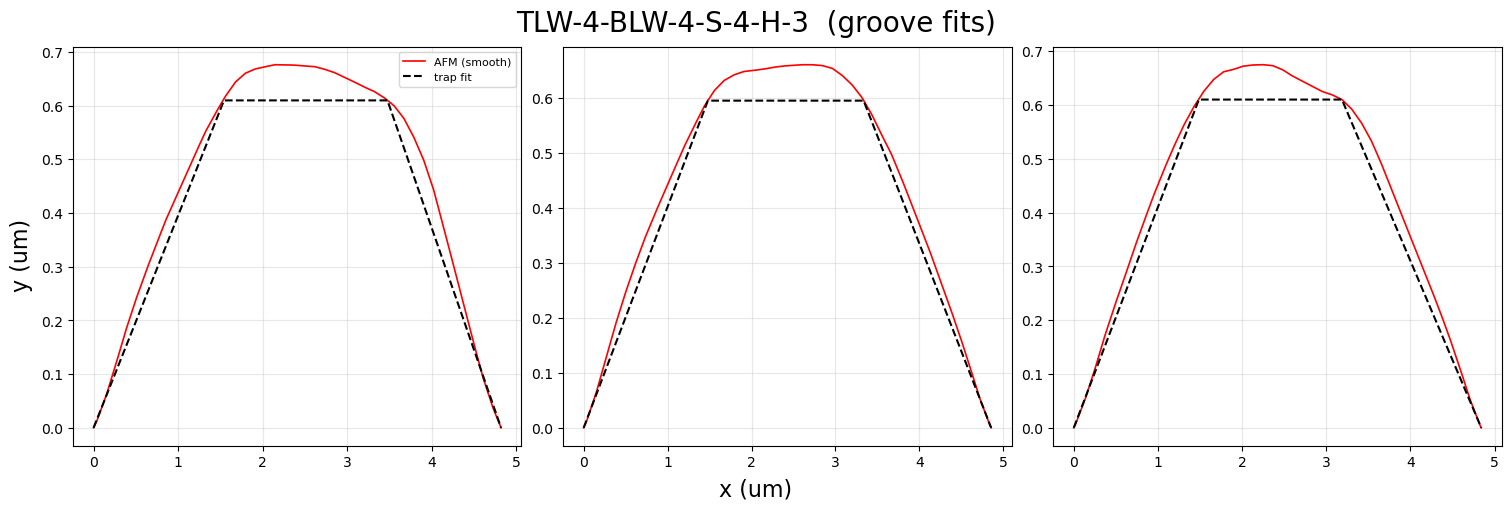

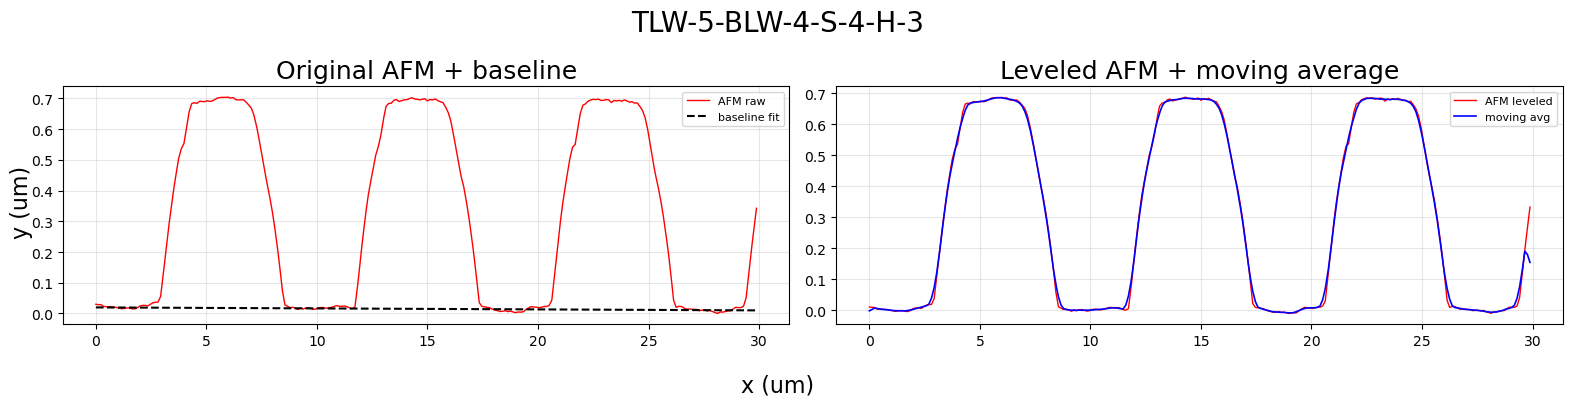

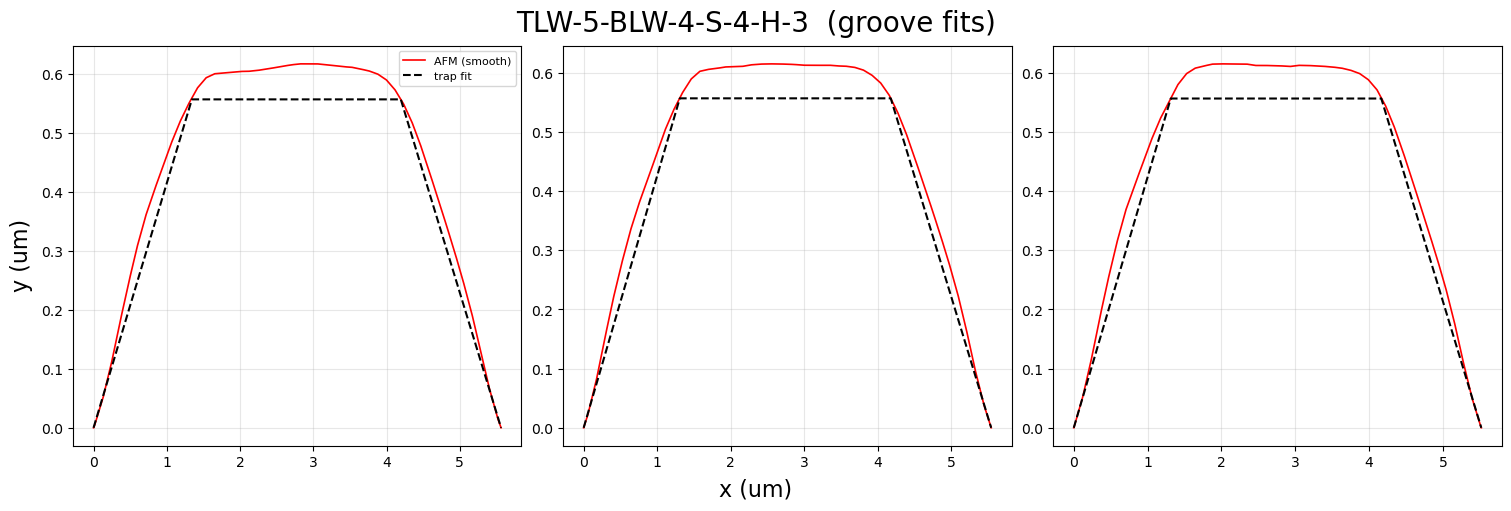

In [52]:
# NRS06032024 / NRS06032024_S-4_H-3_TLW-xx_BLW-4_AFM
REL = 'NRS06032024/NRS06032024_S-4_H-3_TLW-xx_BLW-4_AFM'
afm = process_directory(REL, sample_name='NRS06032024')
plot_grooves_with_fits(afm, REL)

data index = 0
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 3
Number of grooves (smooth) = 3
Fit Heights (um): 0.563 0.571 0.568

data index = 1
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 3
Number of grooves (smooth) = 3
Fit Heights (um): 0.567 0.566 0.564

data index = 2
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 3
Number of grooves (smooth) = 3
Fit Heights (um): 0.56 0.561 0.561

data index = 3
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 2
Number of grooves (smooth) = 2
Fit Heights (um): 0.56 0.556



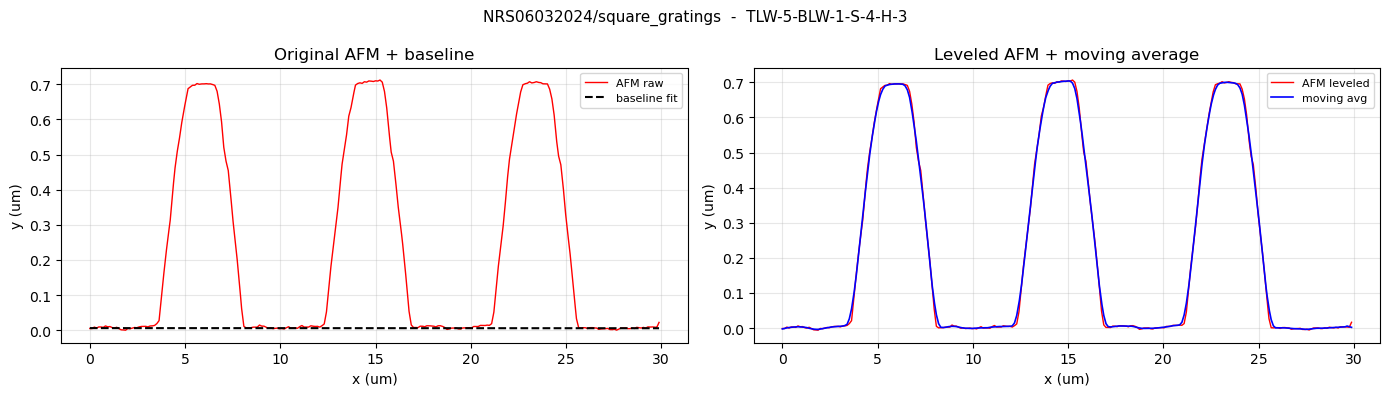

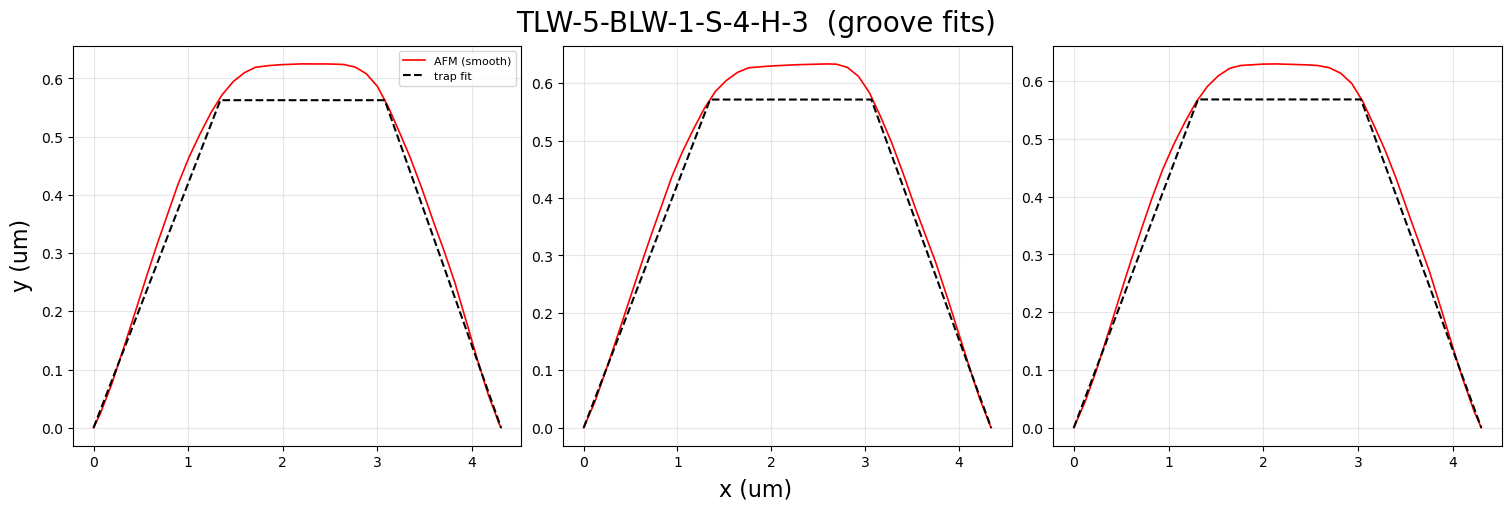

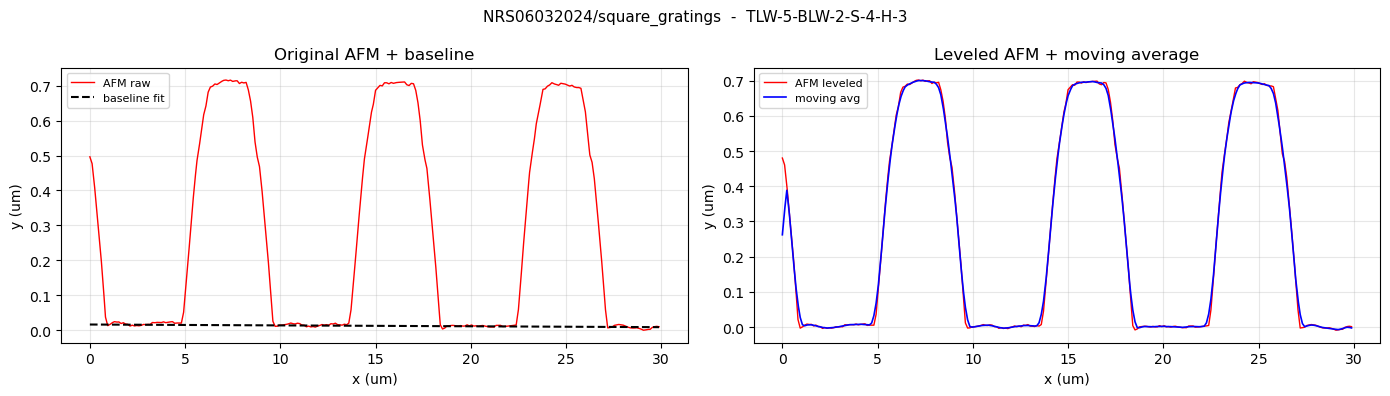

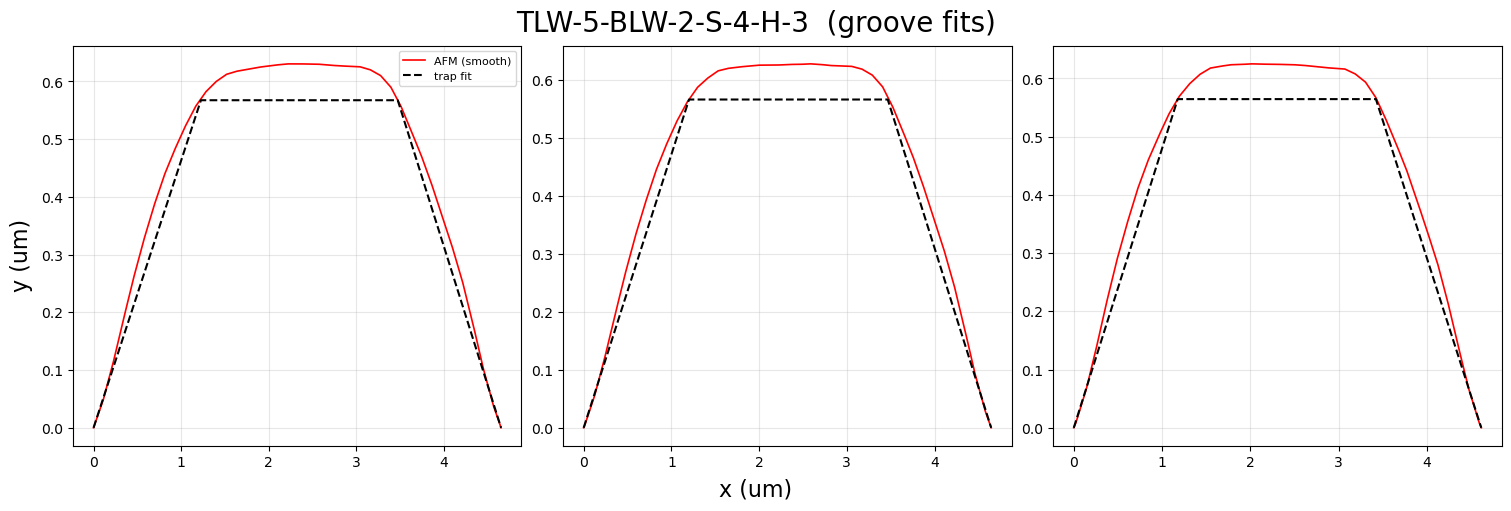

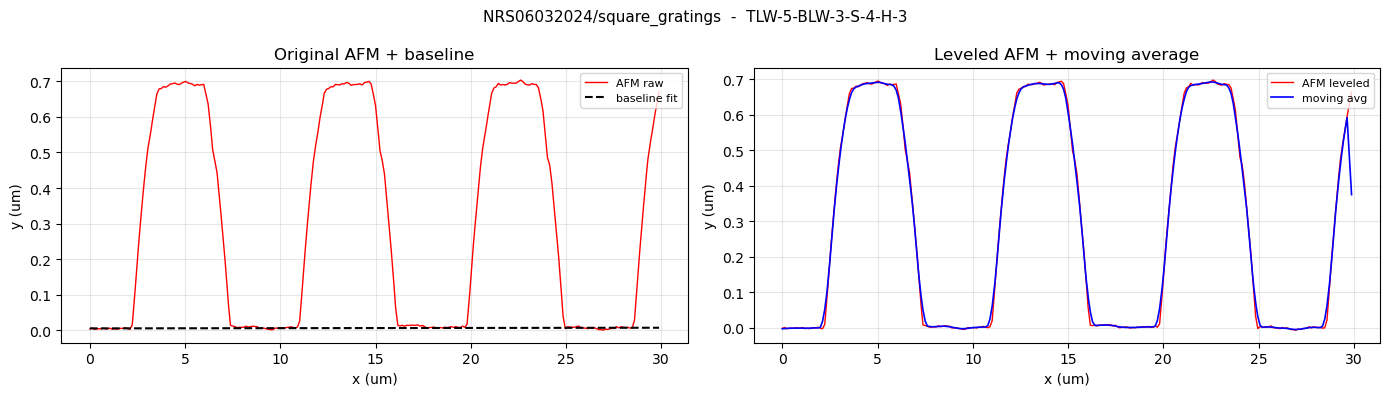

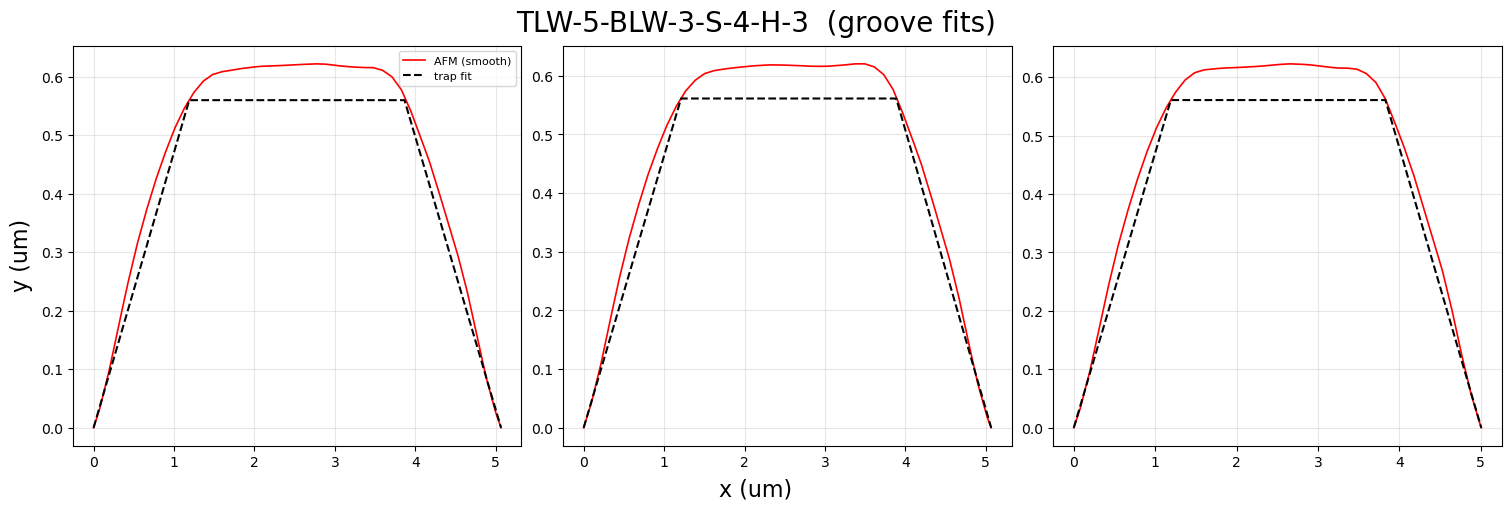

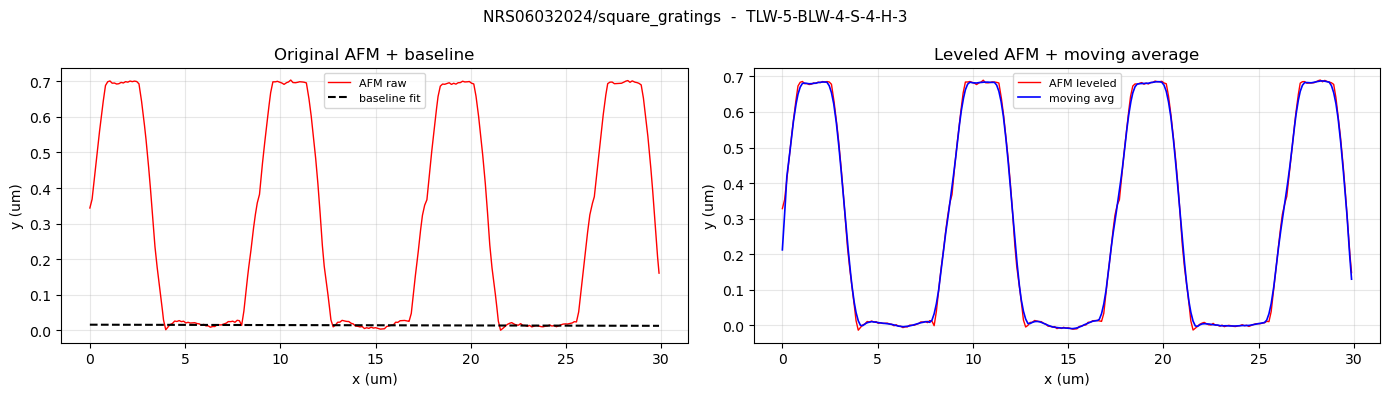

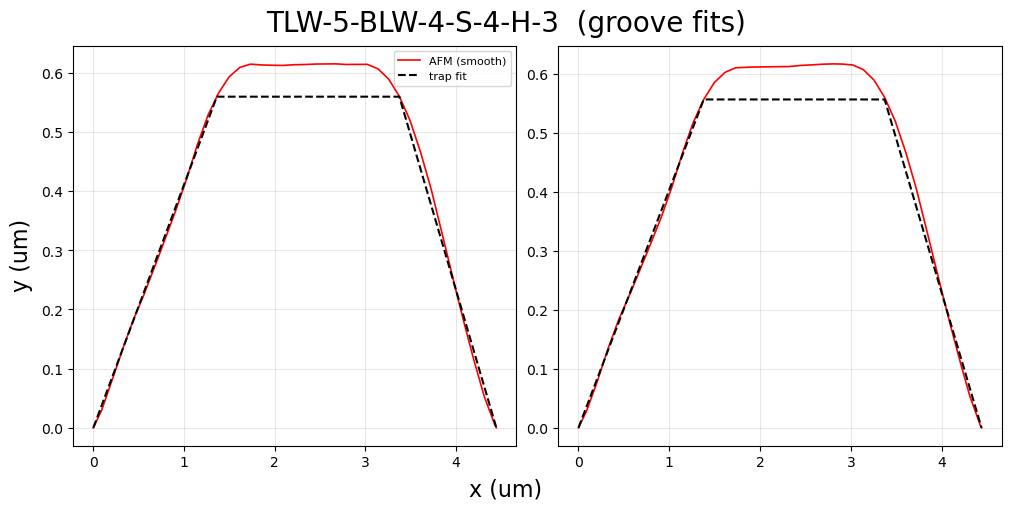

In [38]:
# NRS06032024 / square_gratings
REL = 'NRS06032024/square_gratings'
afm = process_directory(REL, sample_name='NRS06032024')
plot_grooves_with_fits(afm, REL)

## NRS06032024_2

data index = 0
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 4
Number of grooves (smooth) = 4
Fit Heights (um): 0.146 0.146 0.149 0.152

data index = 1
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 4
Number of grooves (smooth) = 4
Fit Heights (um): 0.305 0.306 0.305 0.301

data index = 2
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 4
Number of grooves (smooth) = 4
Fit Heights (um): 0.419 0.417 0.418 0.418

data index = 3
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 4
Number of grooves (smooth) = 4
Fit Heights (um): 0.44 0.441 0.443 0.442

data index = 4
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 4
Number of grooves (smooth) = 4
Fit Heights (um): 0.464 0.46 0.456 0.451



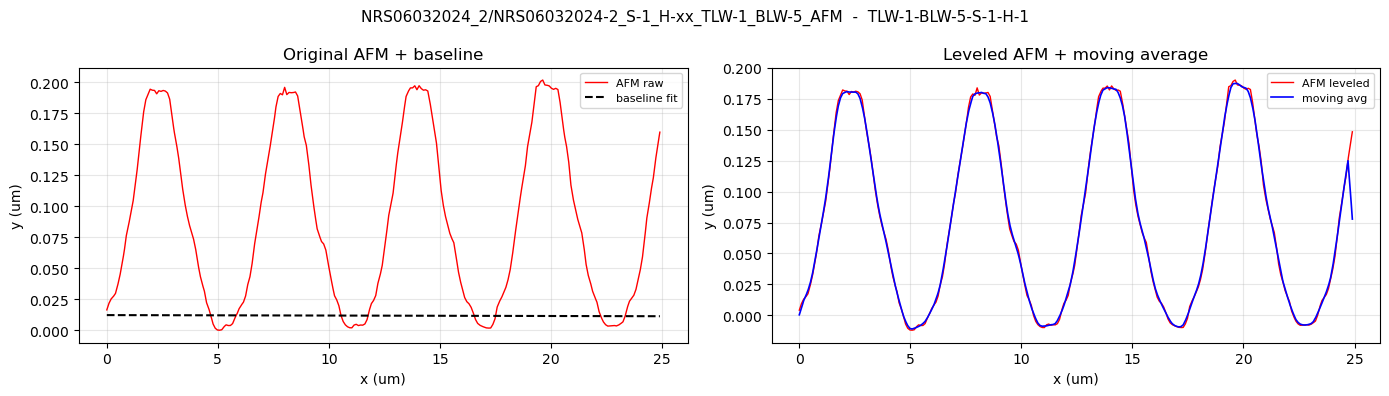

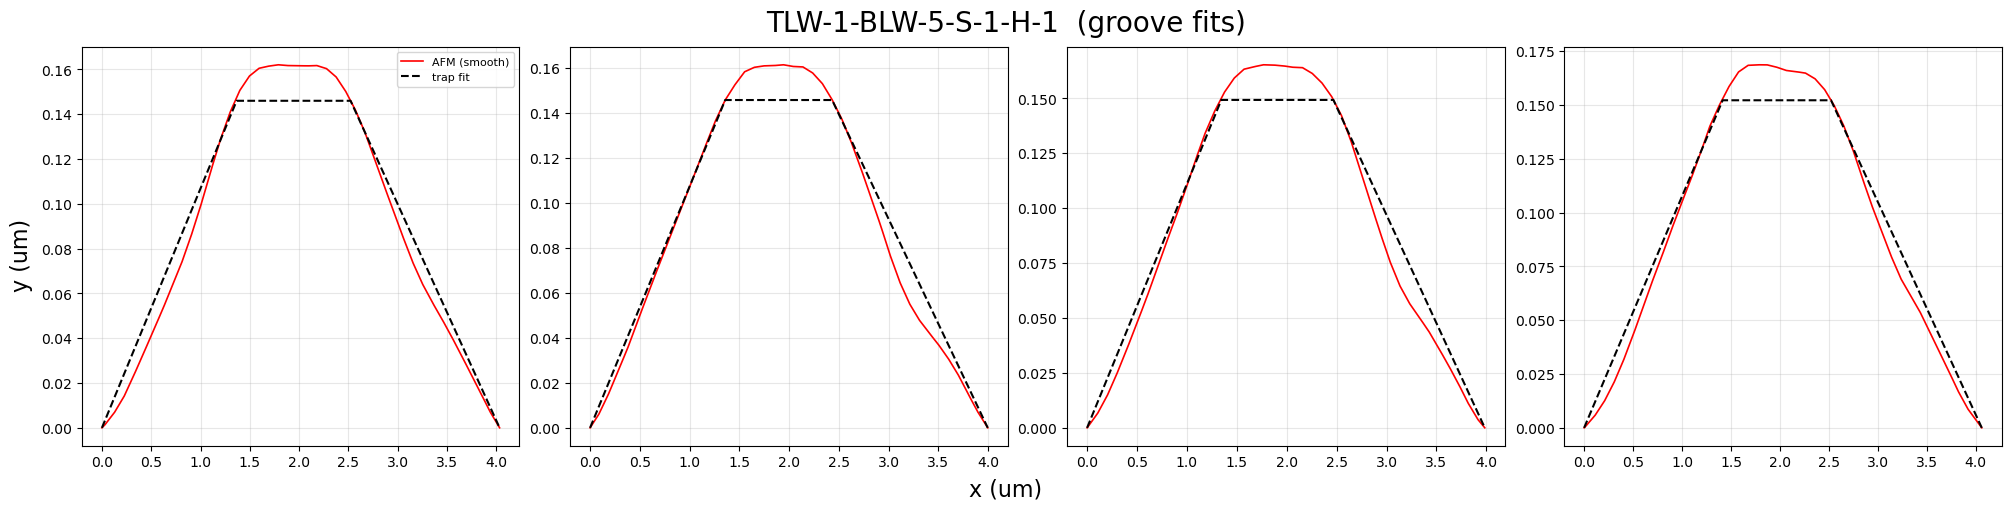

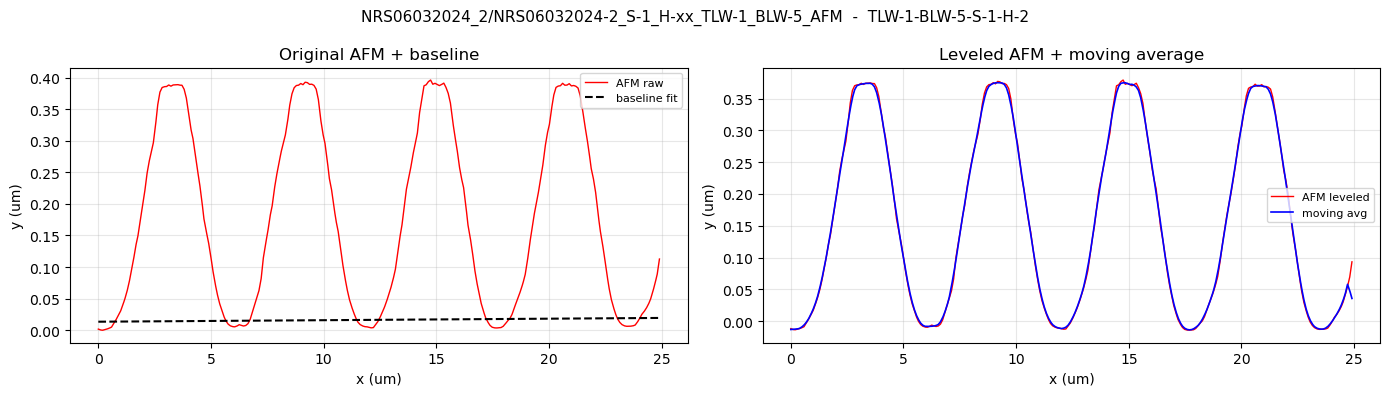

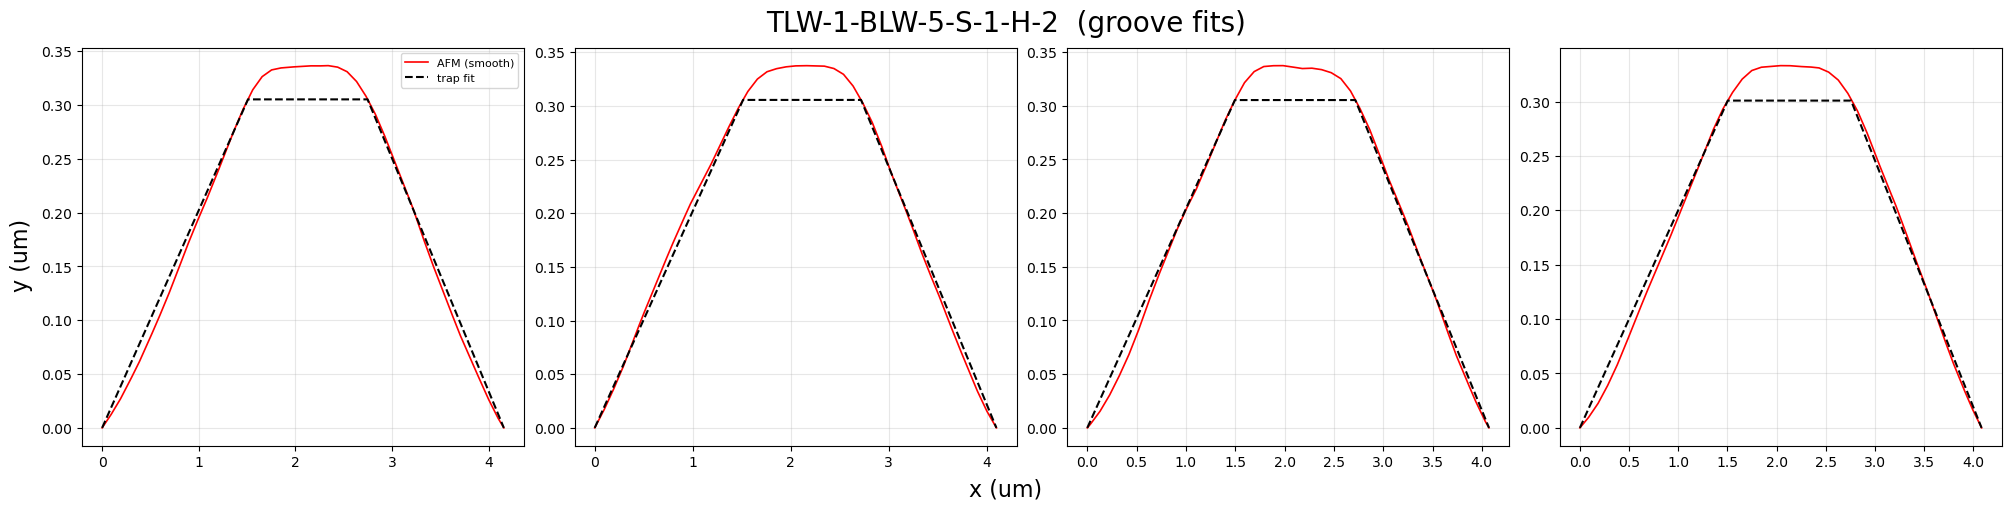

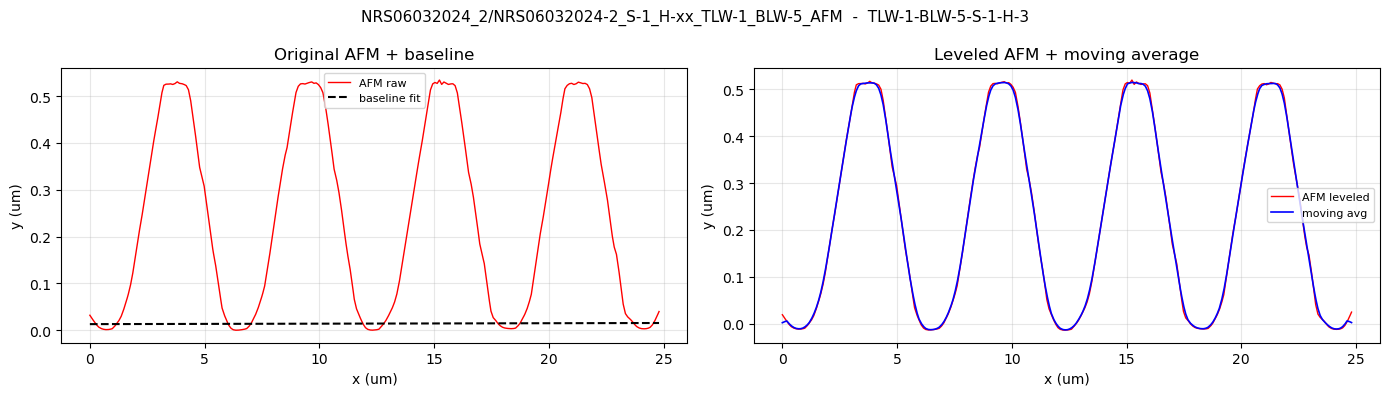

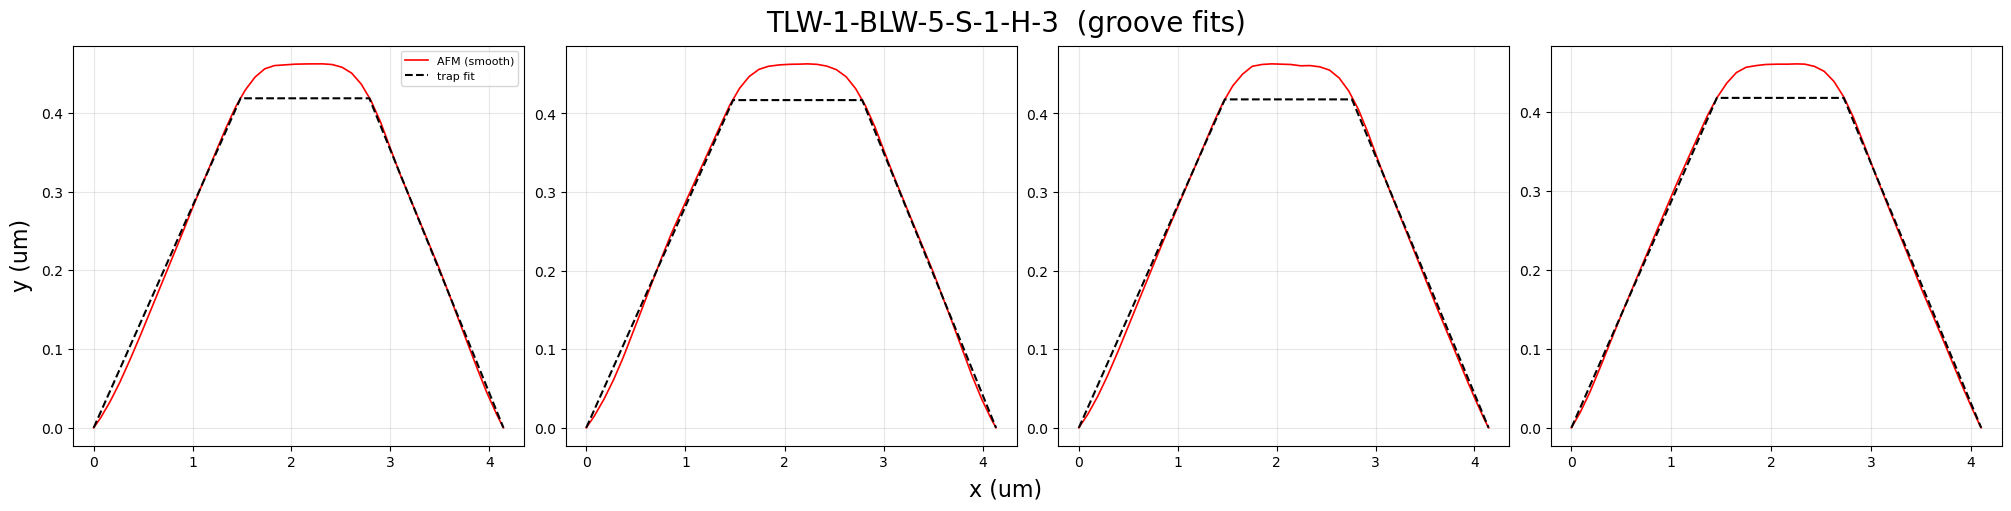

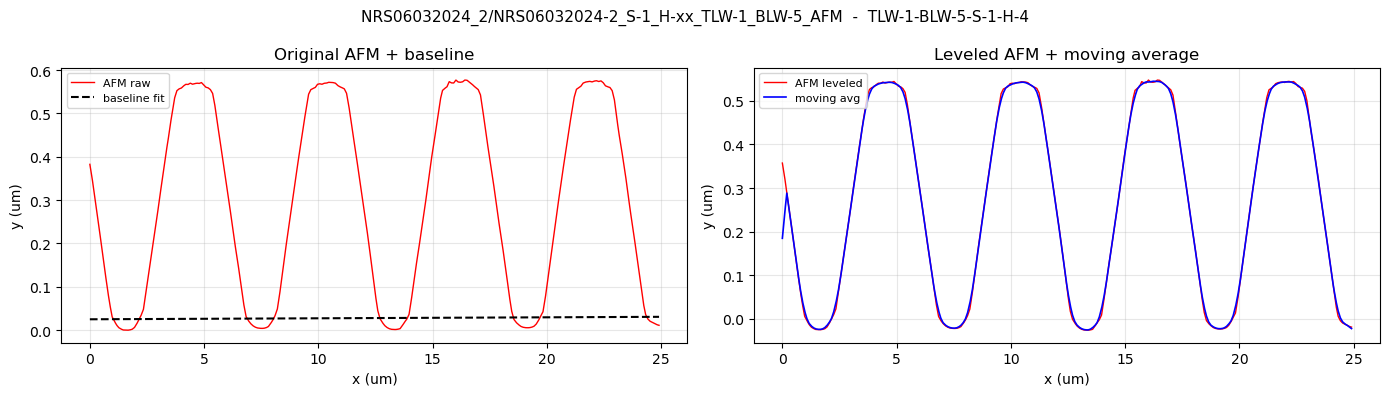

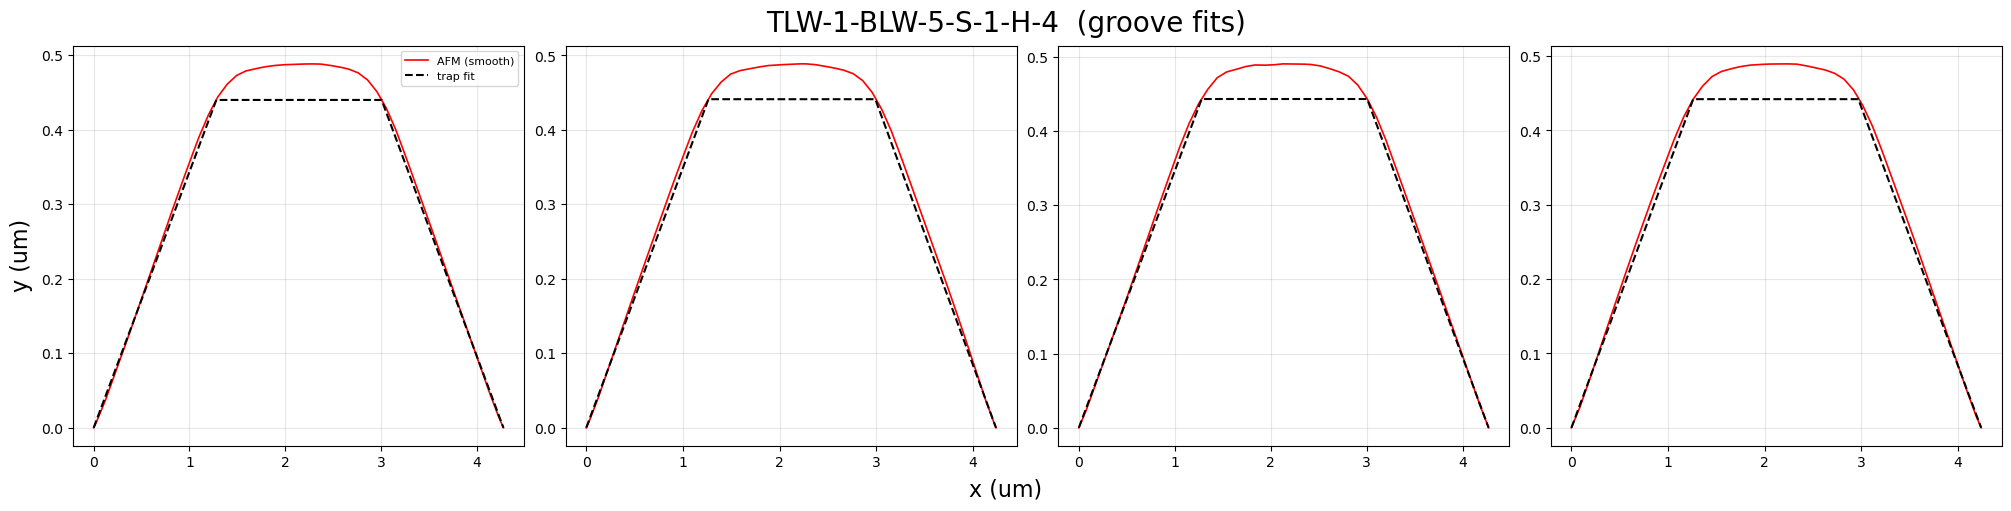

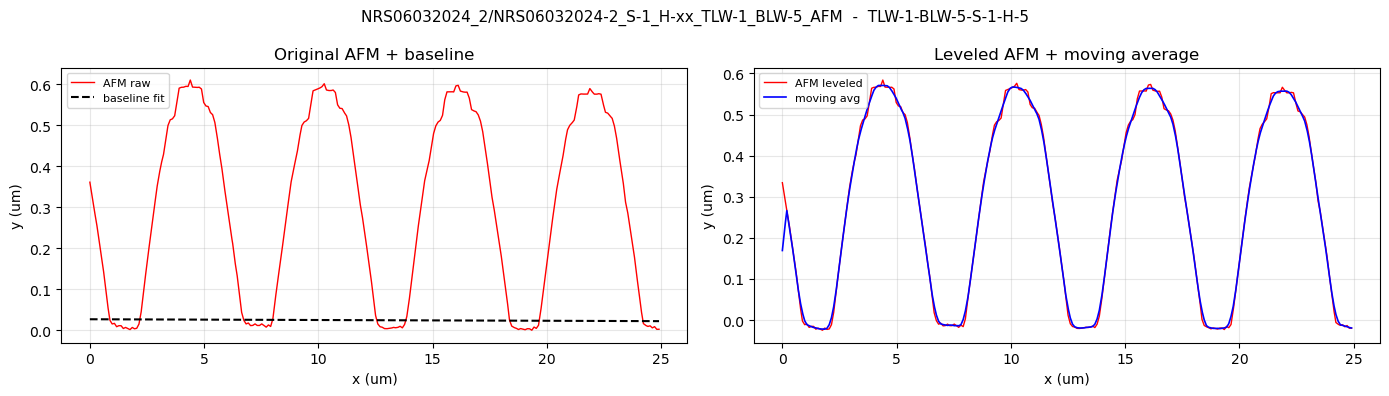

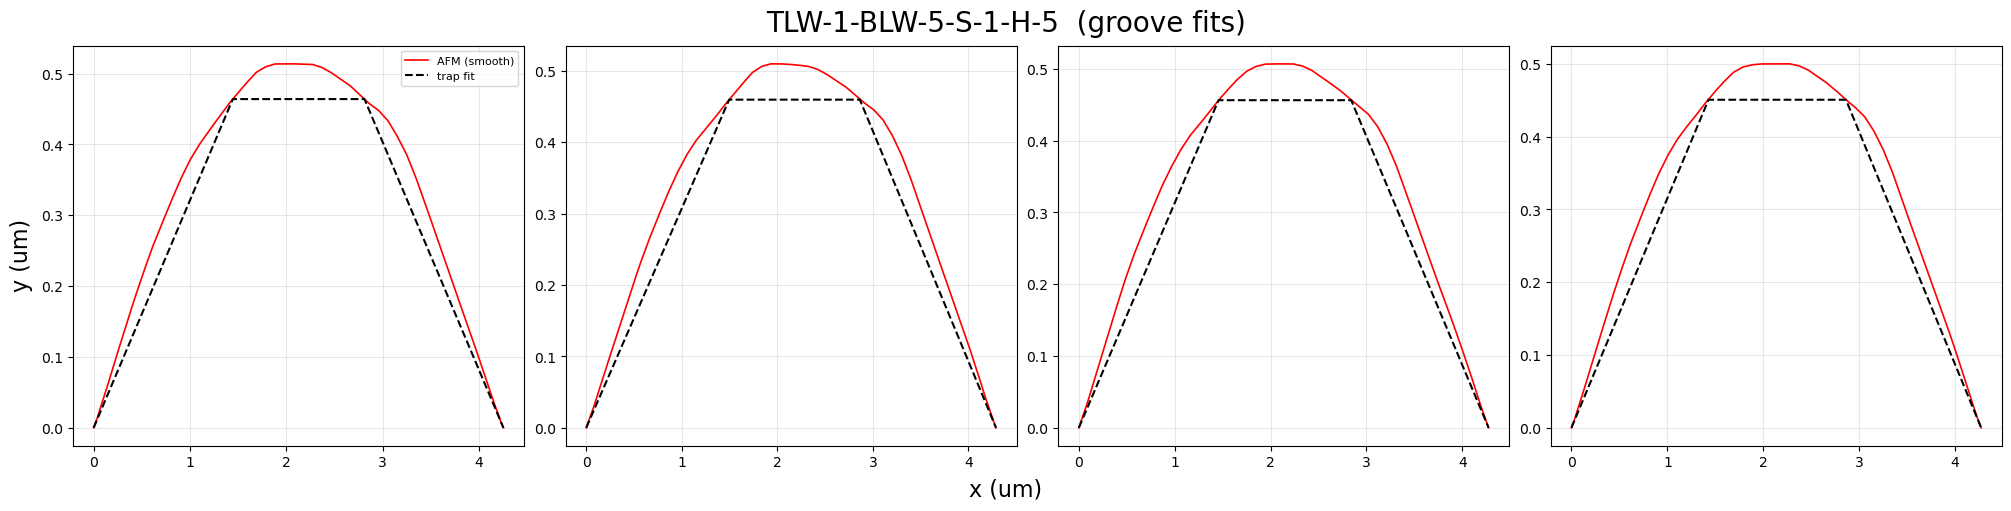

In [39]:
# NRS06032024_2 / NRS06032024-2_S-1_H-xx_TLW-1_BLW-5_AFM
REL = 'NRS06032024_2/NRS06032024-2_S-1_H-xx_TLW-1_BLW-5_AFM'
afm = process_directory(REL, sample_name='NRS06032024_2')
plot_grooves_with_fits(afm, REL)

data index = 0
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 4
Number of grooves (smooth) = 4
Fit Heights (um): 0.278 0.263 0.263 0.265

data index = 1
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 3
Number of grooves (smooth) = 3
Fit Heights (um): 0.294 0.298 0.293

data index = 2
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 3
Number of grooves (smooth) = 3
Fit Heights (um): 0.32 0.319 0.322

data index = 3
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 3
Number of grooves (smooth) = 3
Fit Heights (um): 0.352 0.345 0.346



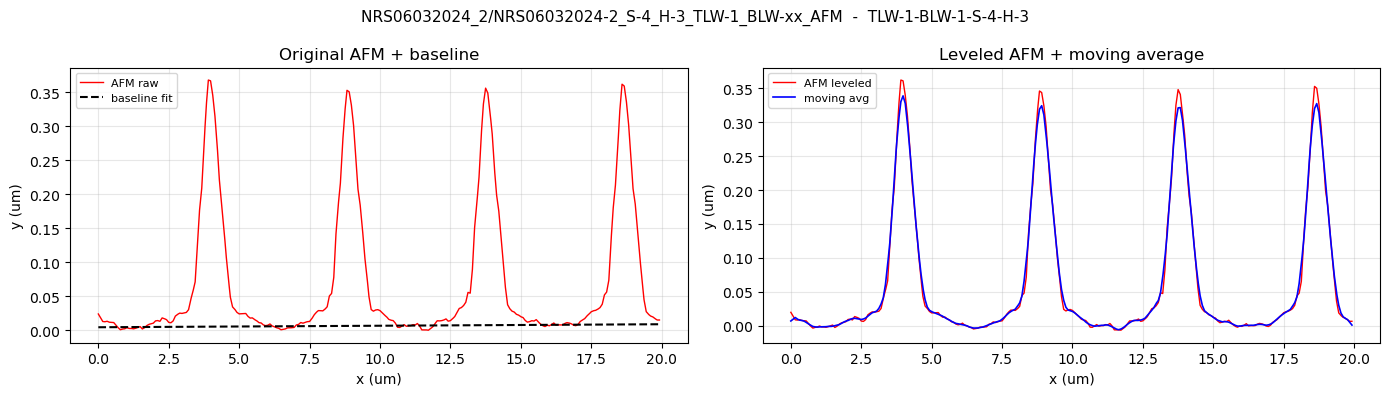

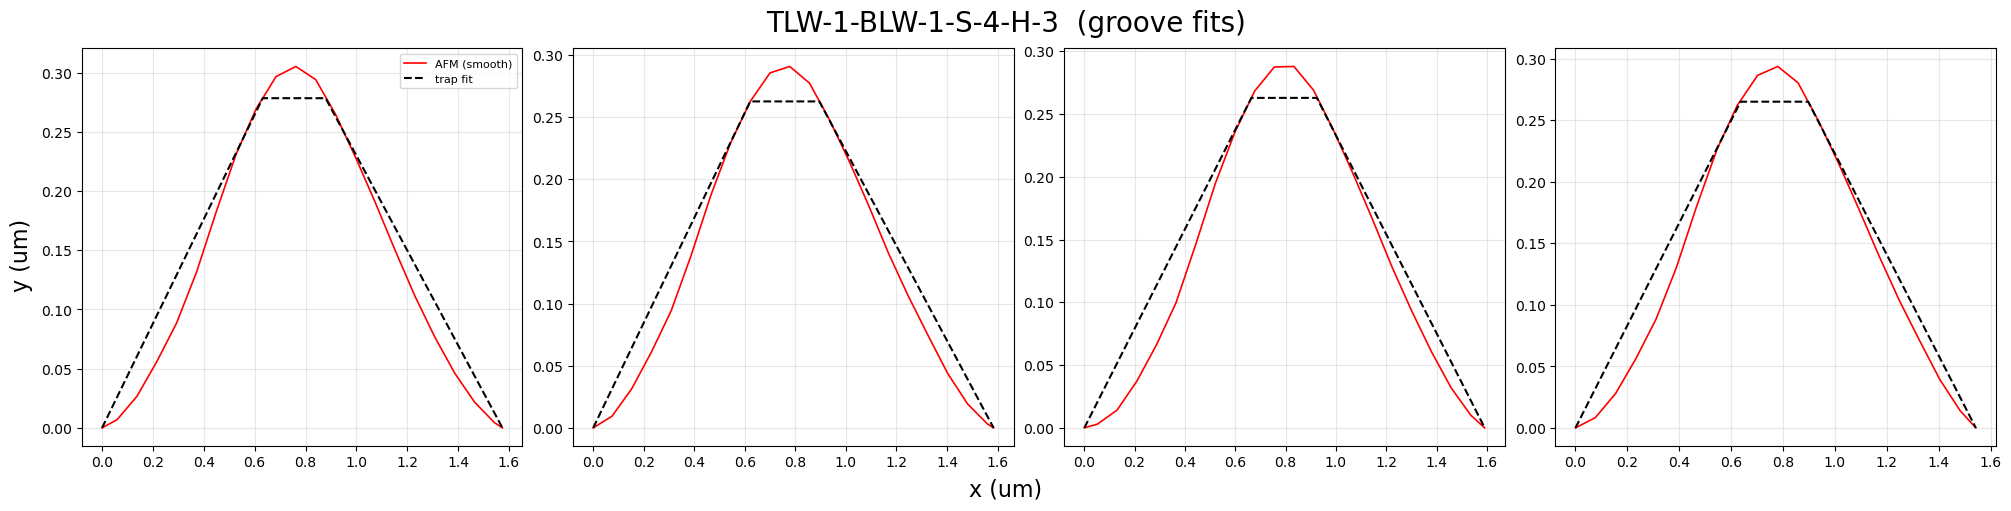

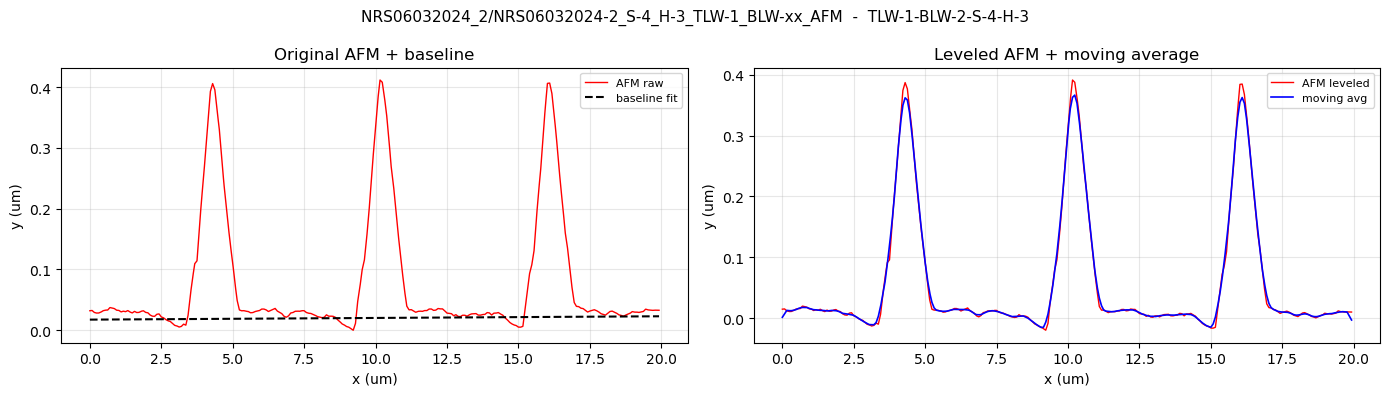

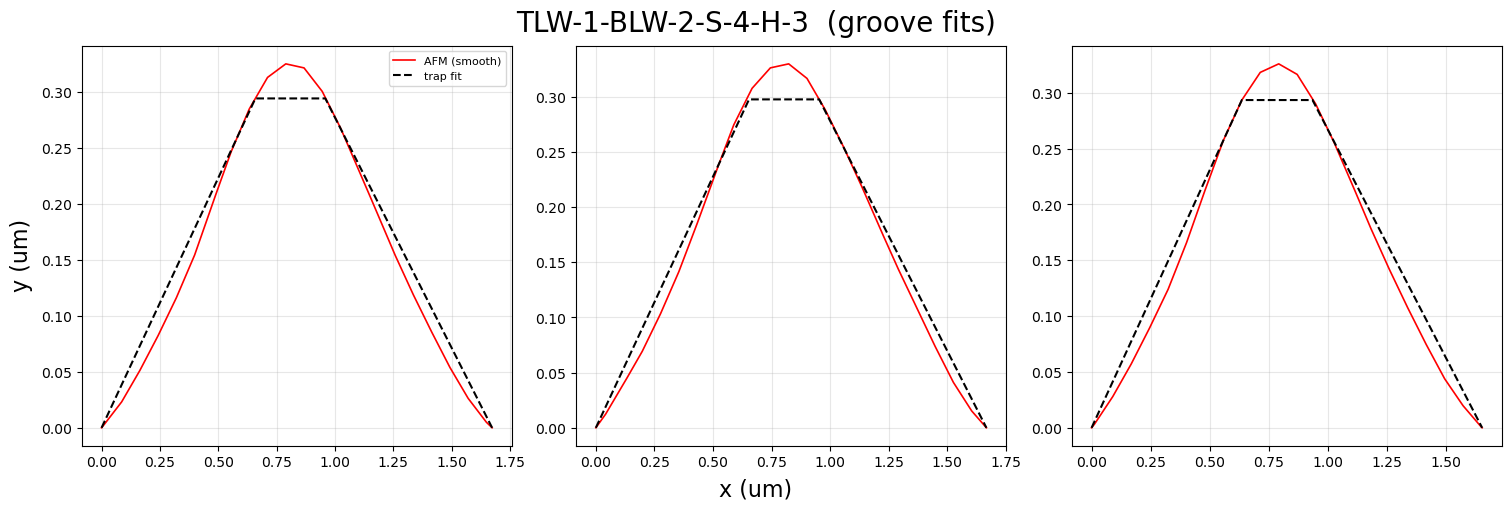

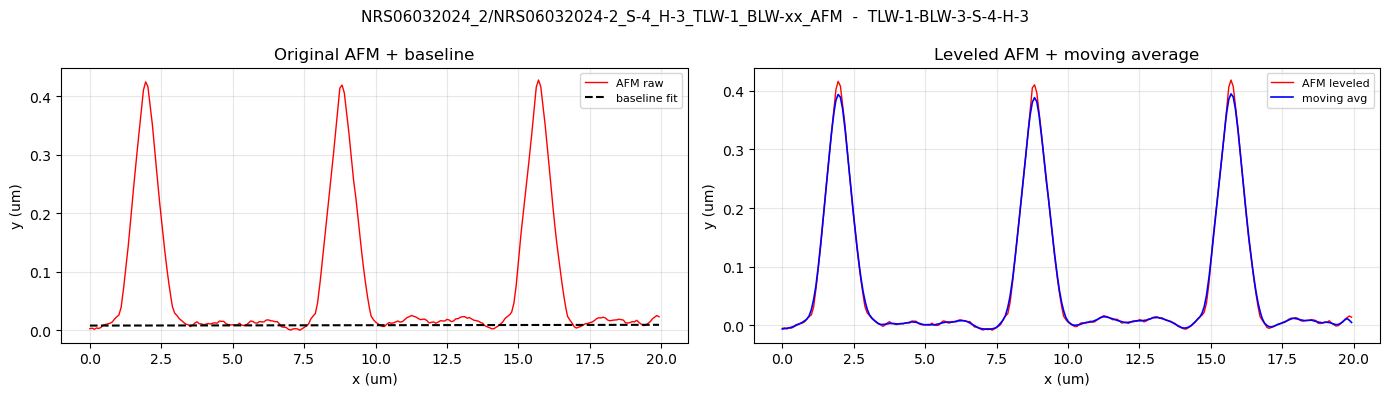

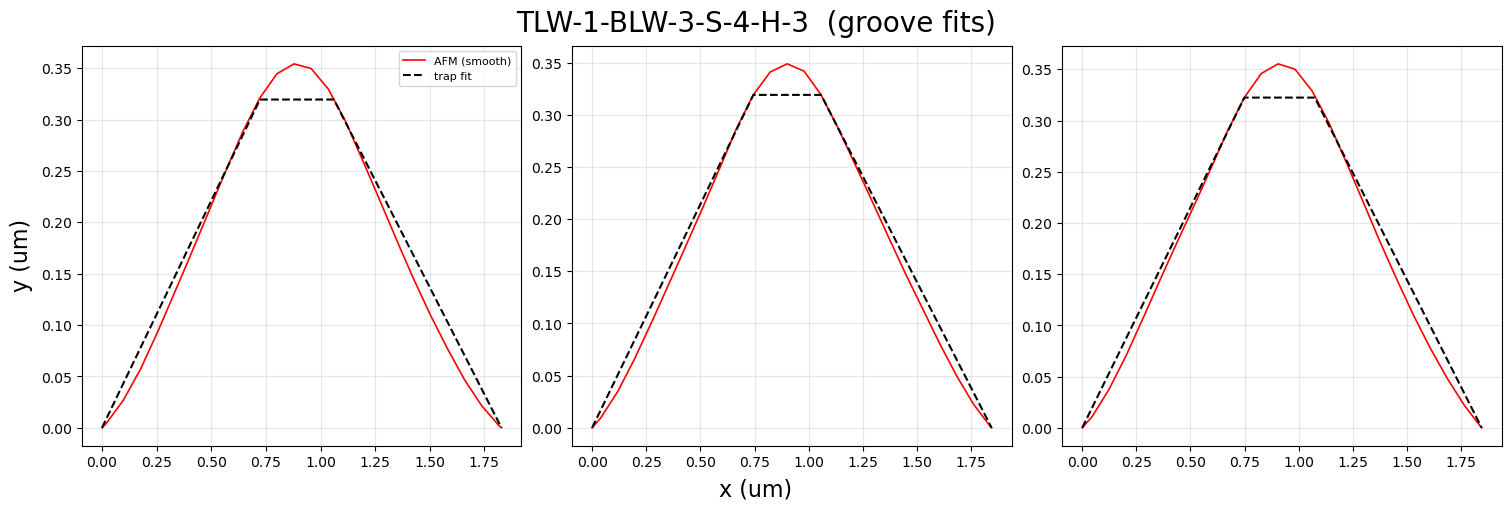

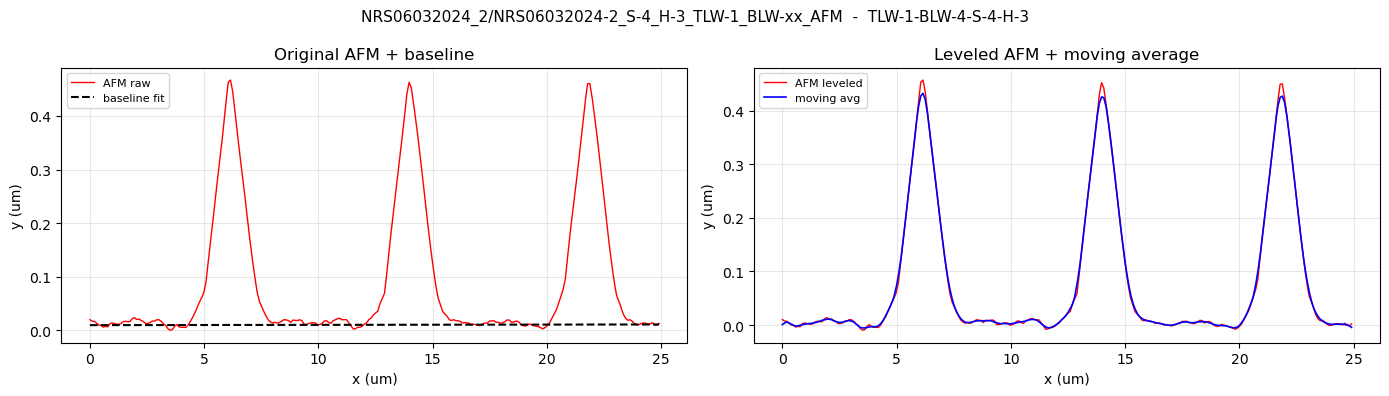

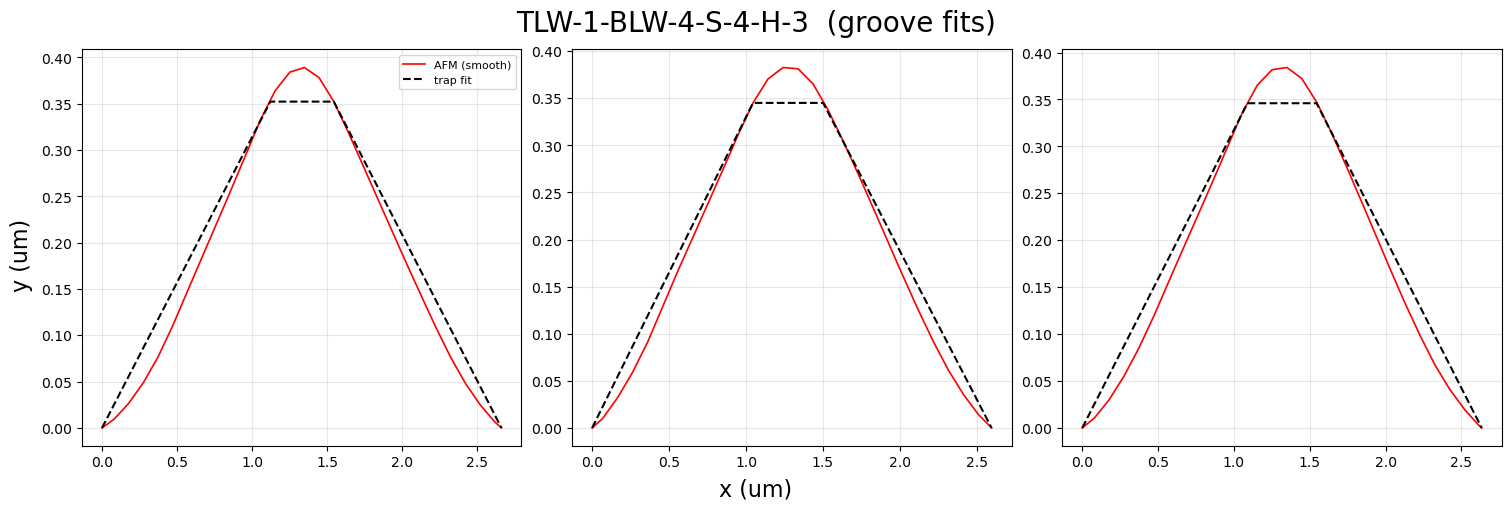

In [40]:
# NRS06032024_2 / NRS06032024-2_S-4_H-3_TLW-1_BLW-xx_AFM
REL = 'NRS06032024_2/NRS06032024-2_S-4_H-3_TLW-1_BLW-xx_AFM'
afm = process_directory(REL, sample_name='NRS06032024_2')
plot_grooves_with_fits(afm, REL)

data index = 0
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 3
Number of grooves (smooth) = 3
Fit Heights (um): 0.332 0.334 0.331

data index = 1
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 4
Number of grooves (smooth) = 4
Fit Heights (um): 0.423 0.424 0.422 0.418

data index = 2
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 4
Number of grooves (smooth) = 4
Fit Heights (um): 0.437 0.431 0.424 0.418

data index = 3
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 3
Number of grooves (smooth) = 3
Fit Heights (um): 0.423 0.42 0.414

data index = 4
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 3
Number of grooves (smooth) = 3
Fit Heights (um): 0.411 0.407 0.401



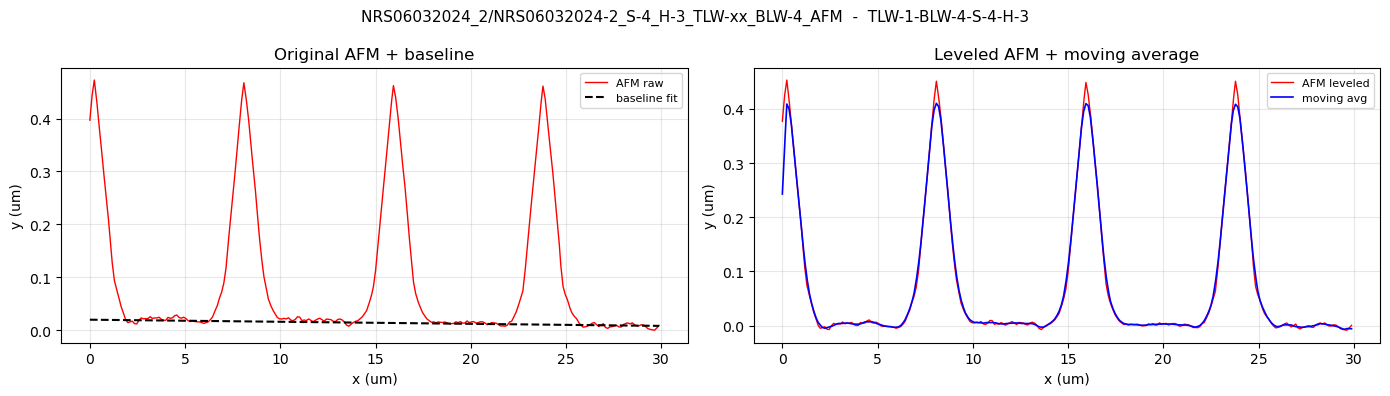

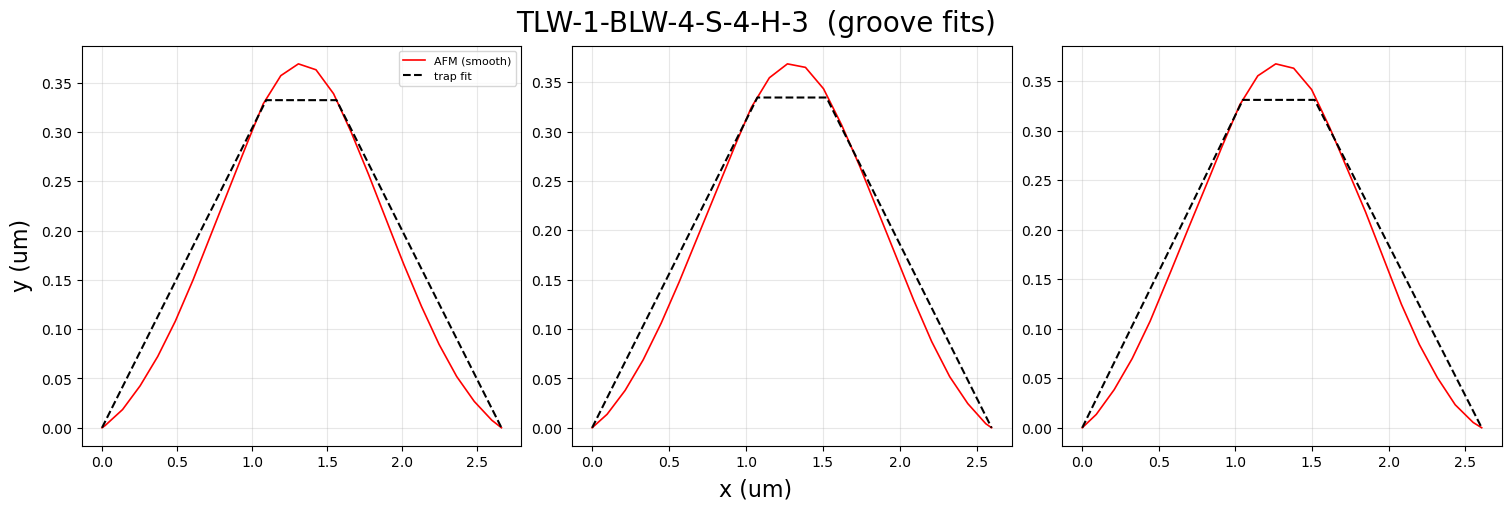

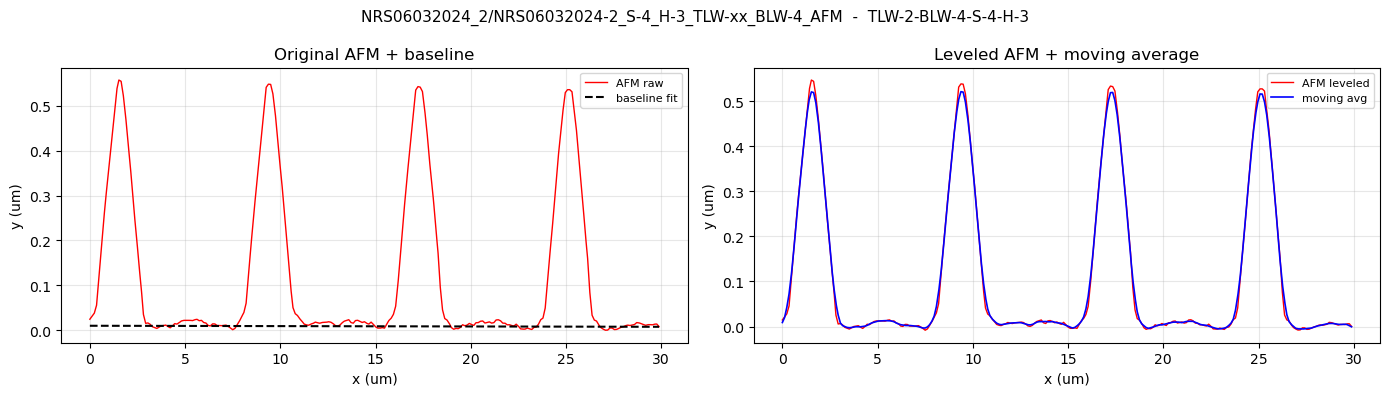

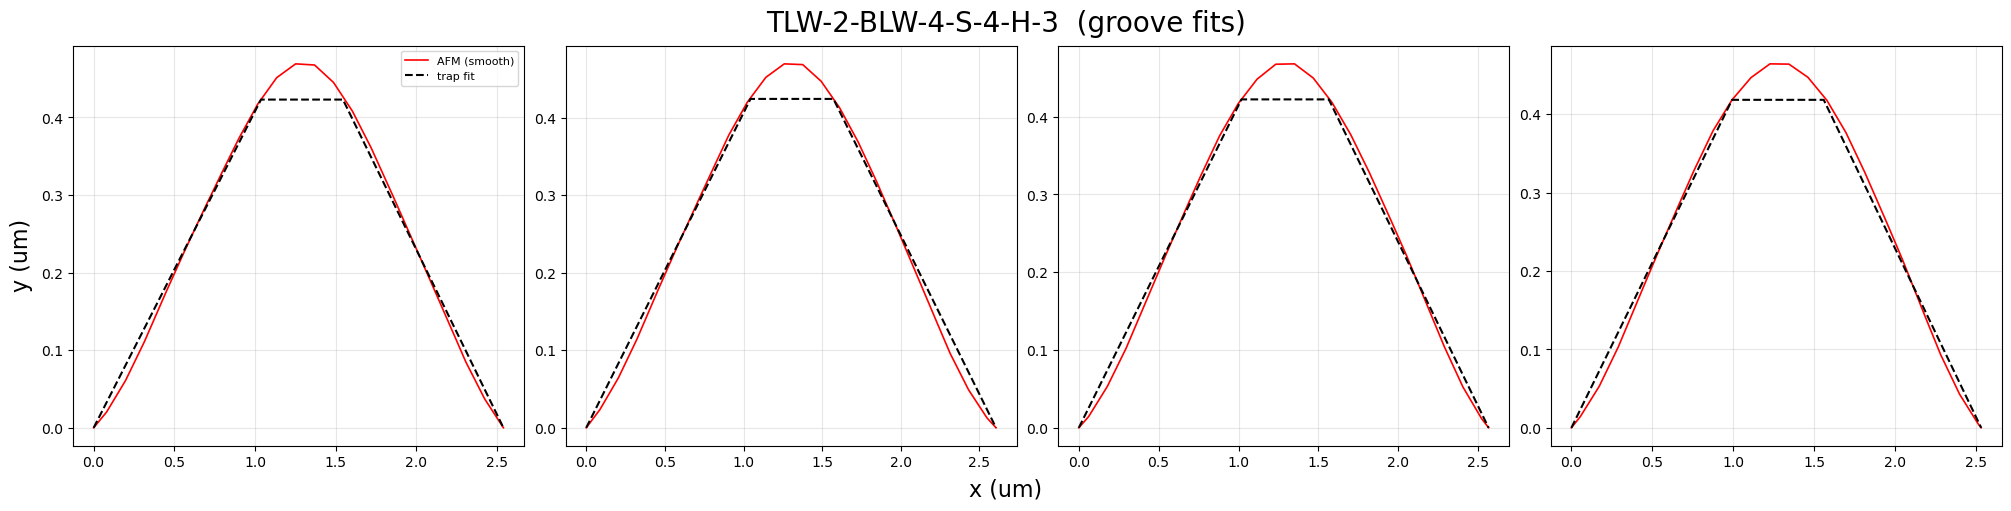

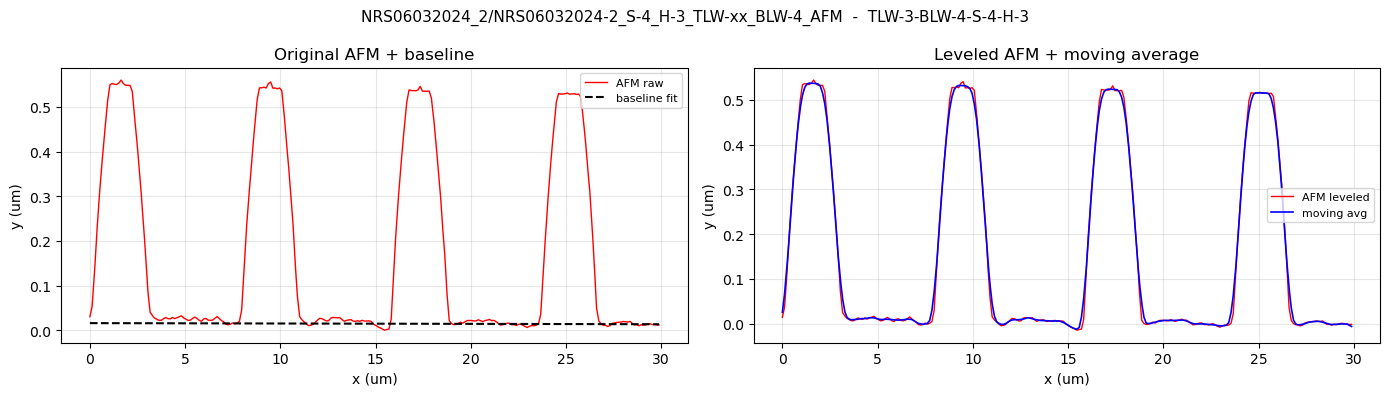

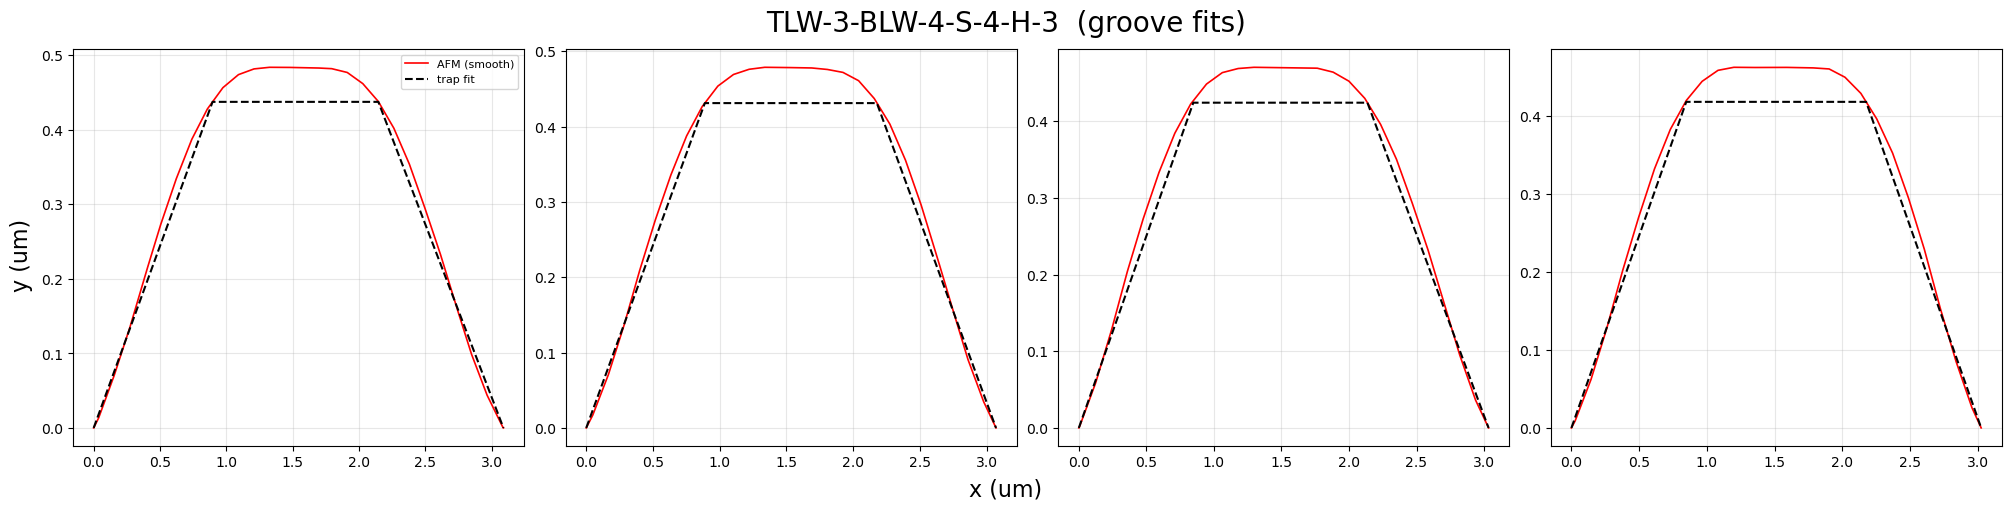

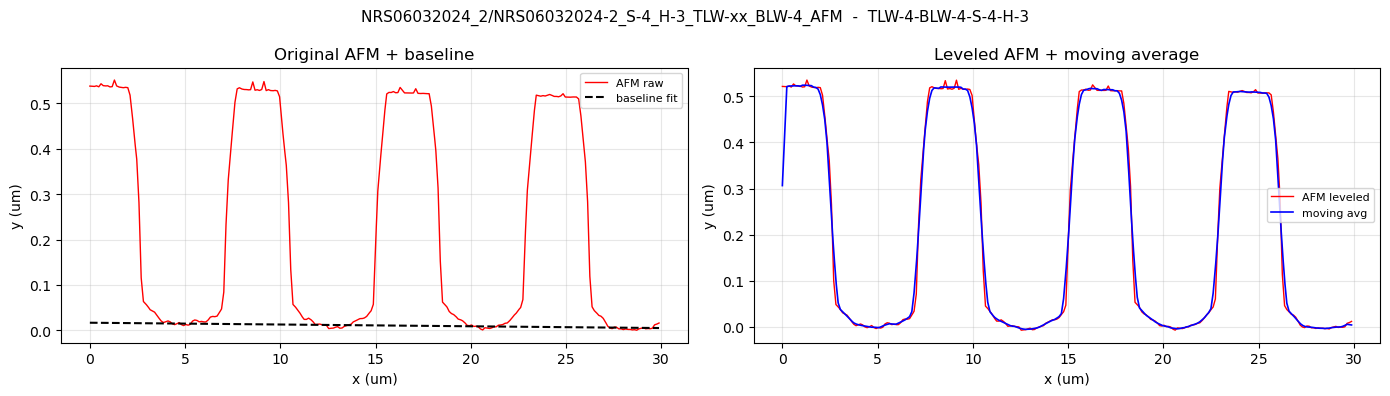

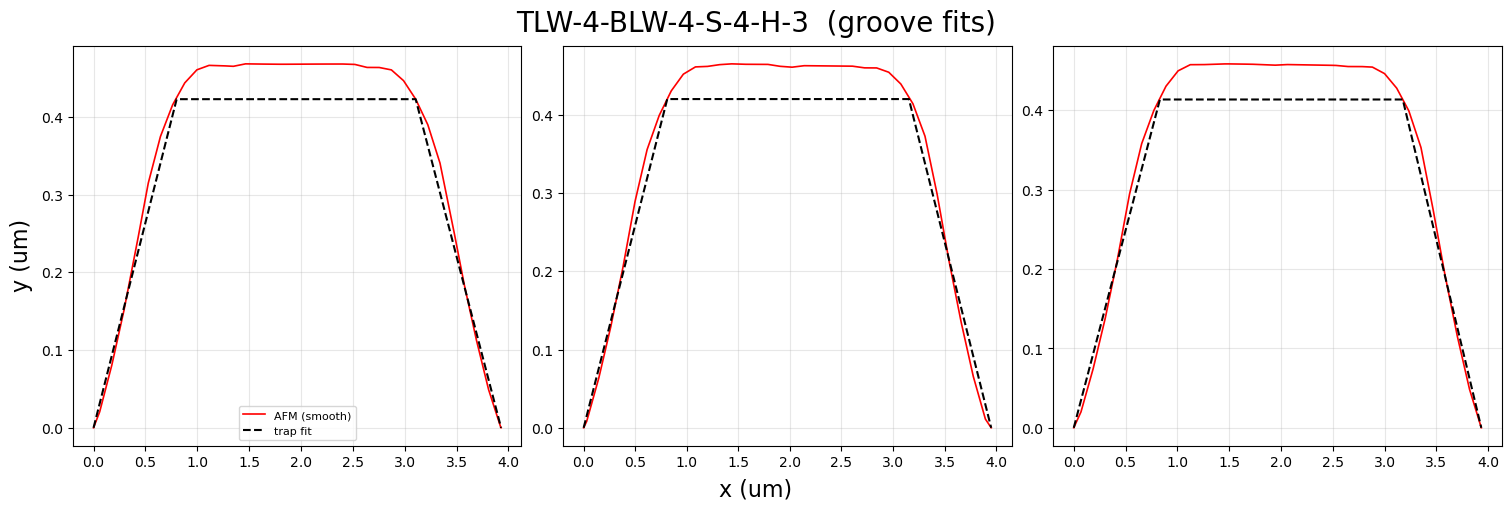

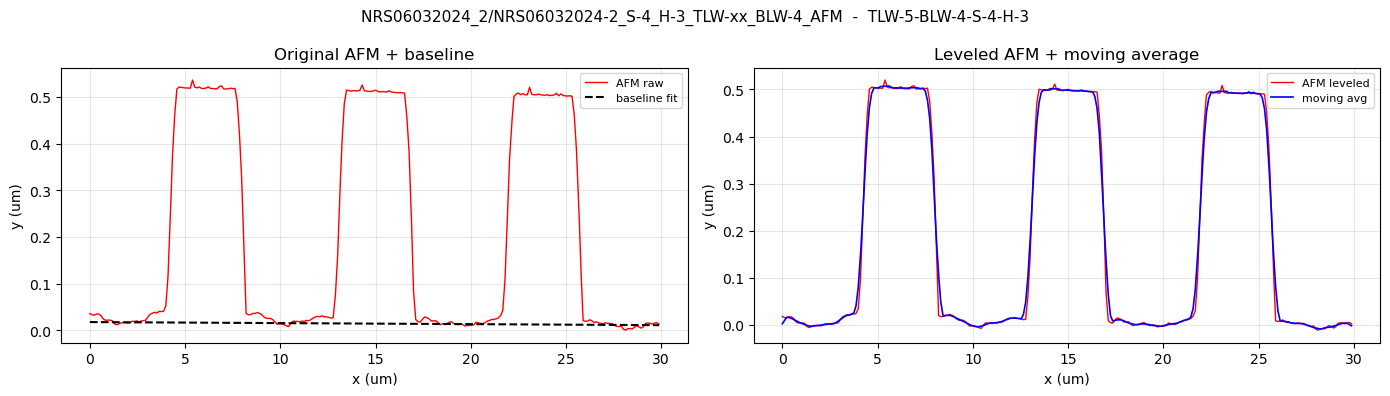

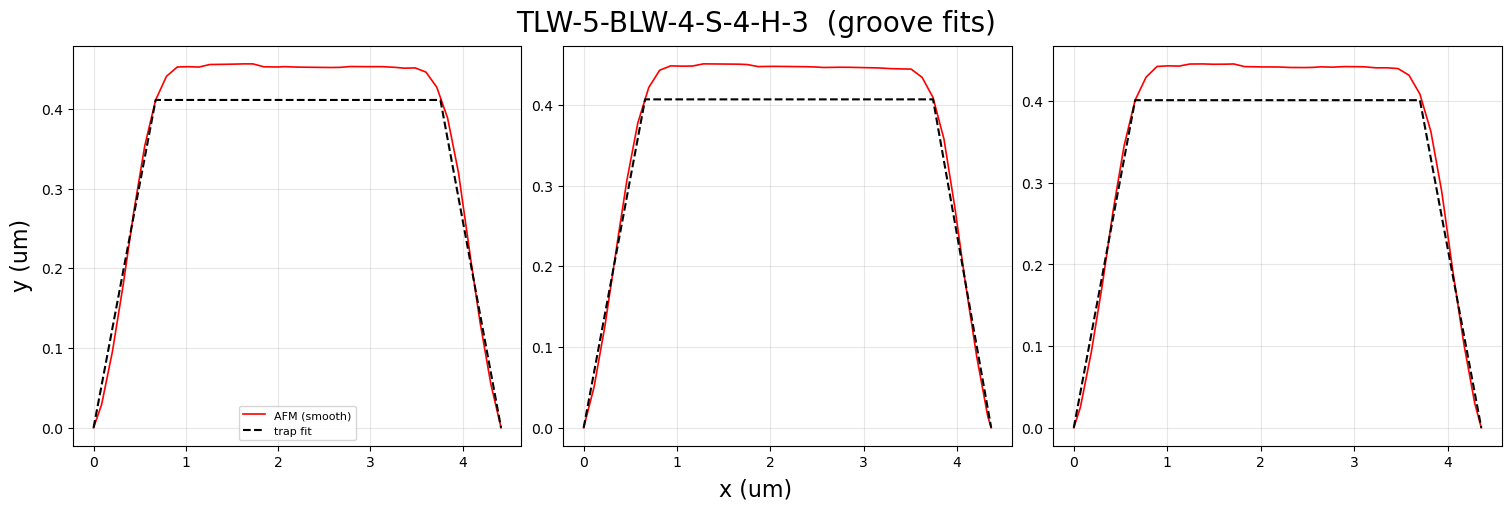

In [41]:
# NRS06032024_2 / NRS06032024-2_S-4_H-3_TLW-xx_BLW-4_AFM
REL = 'NRS06032024_2/NRS06032024-2_S-4_H-3_TLW-xx_BLW-4_AFM'
afm = process_directory(REL, sample_name='NRS06032024_2')
plot_grooves_with_fits(afm, REL)

data index = 0
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 3
Number of grooves (smooth) = 3
Fit Heights (um): 0.418 0.413 0.405

data index = 1
tlw level = 0.9
blw level = 0.1
window size = 5
Number of grooves (raw) = 3
Number of grooves (smooth) = 3
Fit Heights (um): 0.413 0.415 0.41



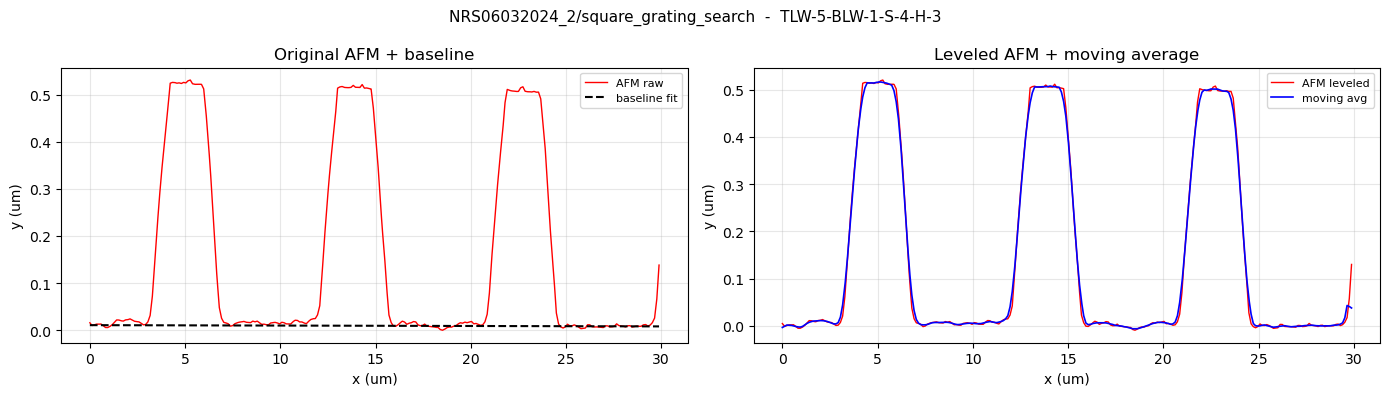

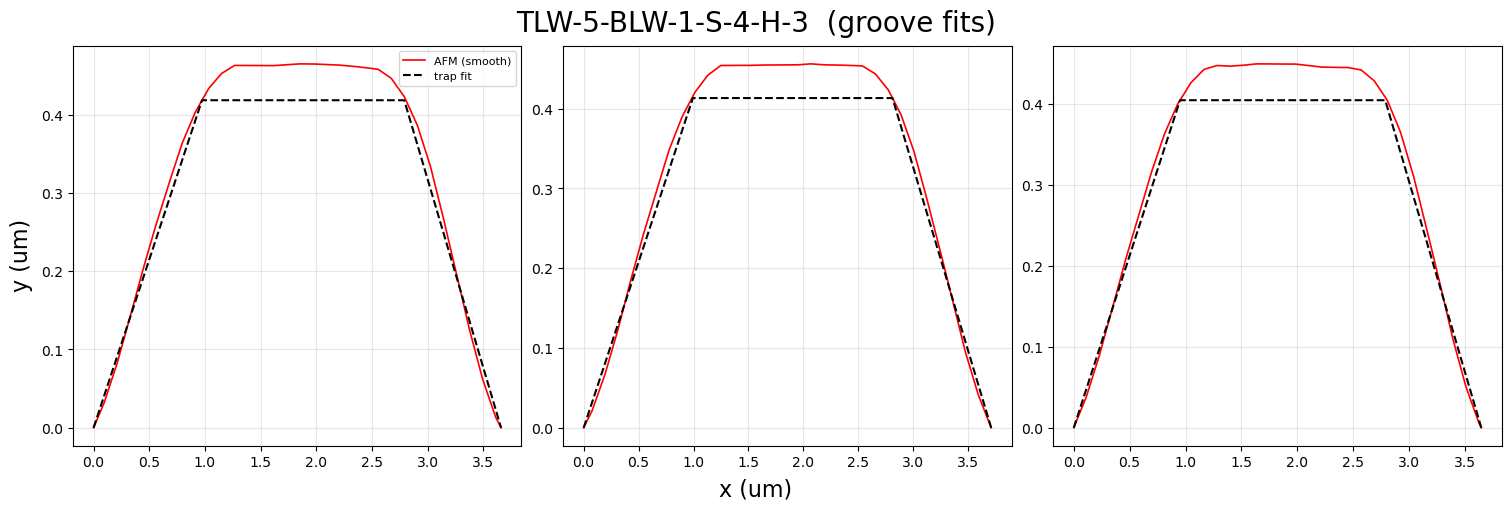

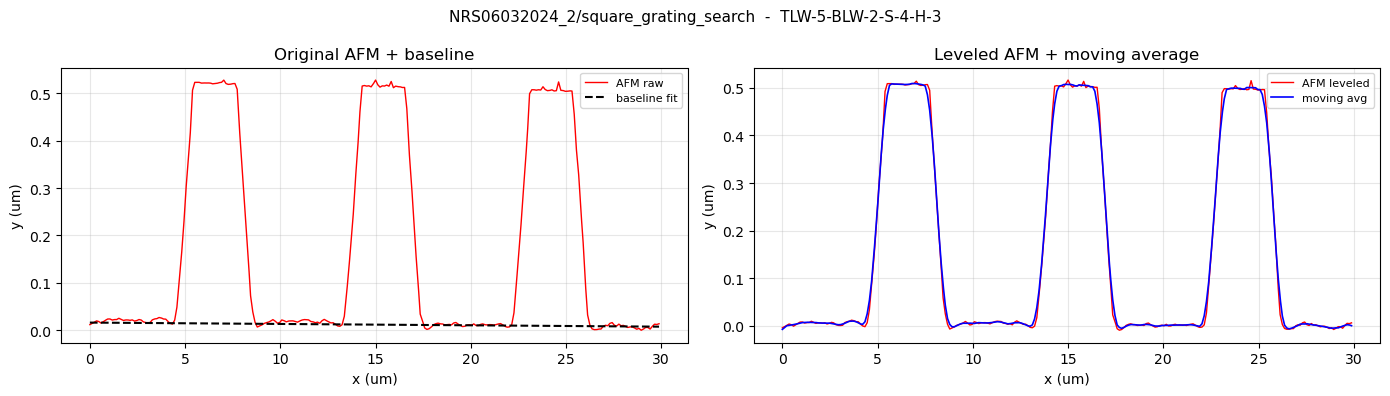

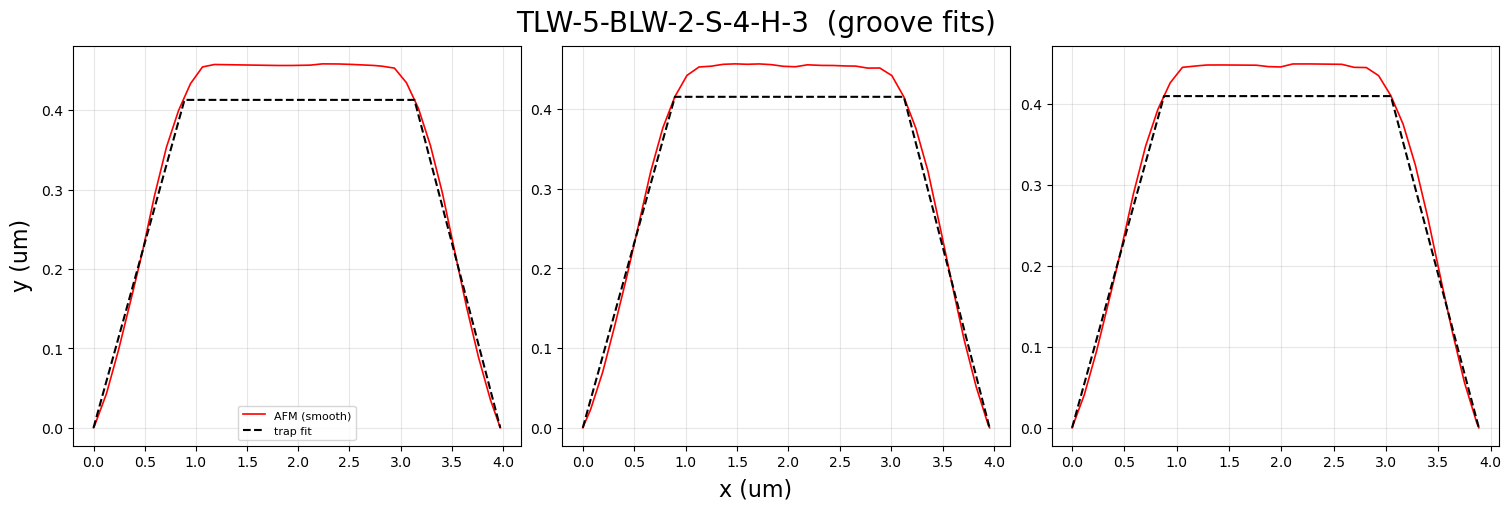

In [42]:
# NRS06032024_2 / square_grating_search
REL = 'NRS06032024_2/square_grating_search'
afm = process_directory(REL, sample_name='NRS06032024_2')
plot_grooves_with_fits(afm, REL)

## Top-3 rankings across all measurement files

Each `.txt` file contributes one number per metric: the per-file mean across its grooves. RMSE is averaged from `record['rmse']`; squareness uses the per-file `sTLW mean` and `sBLW mean`.

Top 5 RMSE (lowest = best fit)
-----------------------------------------------------------------------------------------------
  1. TLW-1-BLW-5-S-1-H-1.txt                   rmse=0.00953  TLW=1.115  BLW=4.018  (NRS06032024_2)
  2. TLW-1-BLW-3-S-4-H-3.txt                   rmse=0.01509  TLW=0.326  BLW=1.839  (NRS06032024_2)
  3. TLW-1-BLW-5-S-1-H-2.txt                   rmse=0.01572  TLW=1.229  BLW=4.103  (NRS06032024_2)
  4. TLW-1-BLW-4-S-4-H-3.txt                   rmse=0.01586  TLW=0.918  BLW=3.069  (NRS06032024)
  5. TLW-1-BLW-2-S-4-H-3.txt                   rmse=0.01654  TLW=0.299  BLW=1.665  (NRS06032024_2)

Top 5 closest to TLW = BLW (smallest |sTLW - sBLW|)
-----------------------------------------------------------------------------------------------
  1. TLW-1-BLW-1-S-4-H-3.txt                   |TLW-BLW|=1.3129  TLW=0.260  BLW=1.573  (NRS06032024_2)
  2. TLW-5-BLW-4-S-4-H-3.txt                   |TLW-BLW|=1.3148  TLW=3.066  BLW=4.381  (NRS06032024_2)
  3. TLW-1-BLW-2-S-4-H-3.

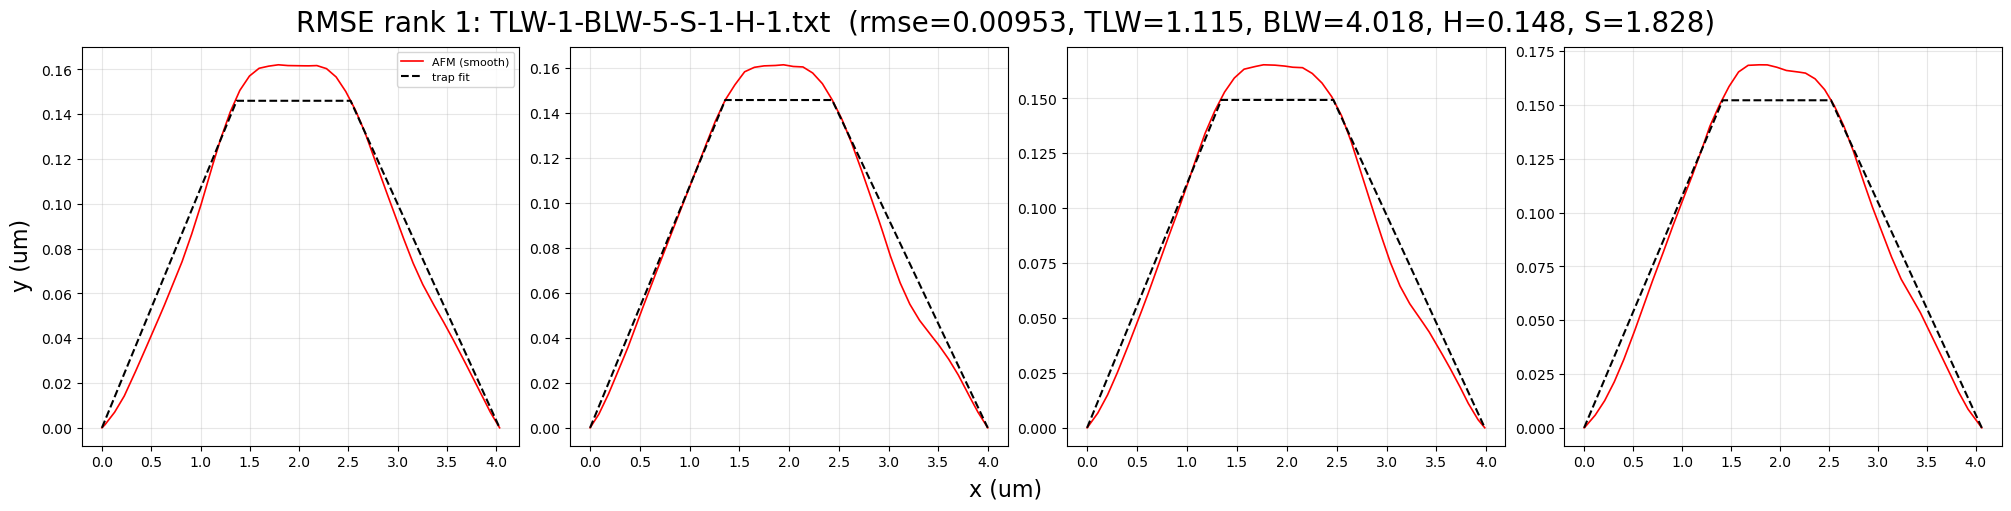

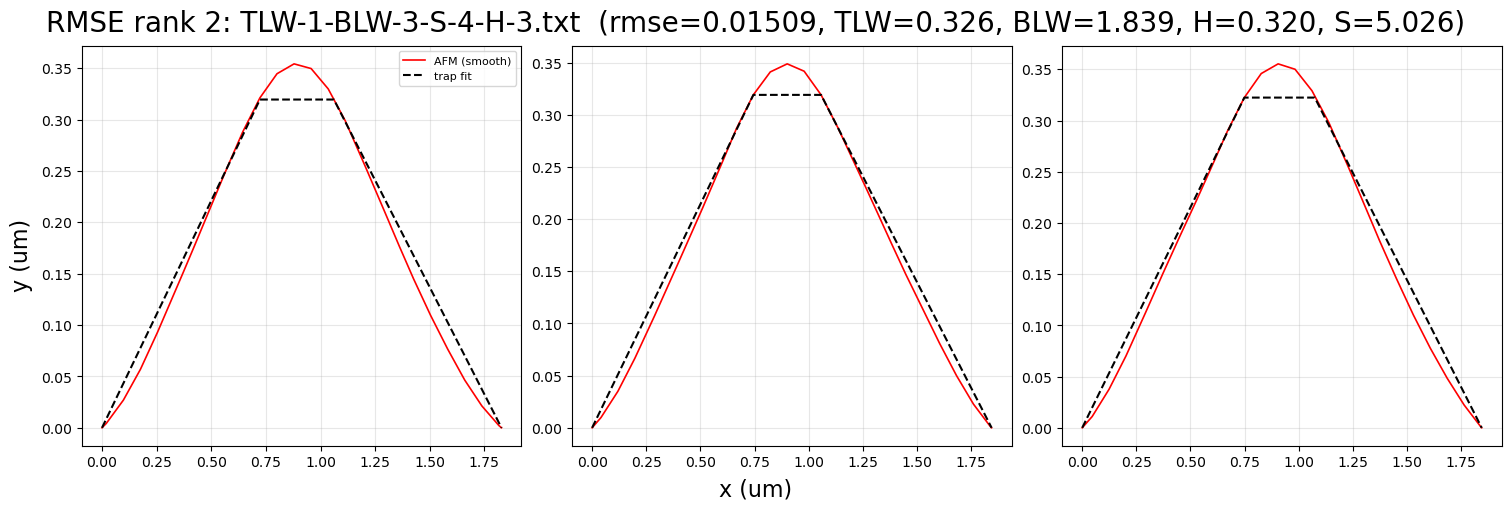

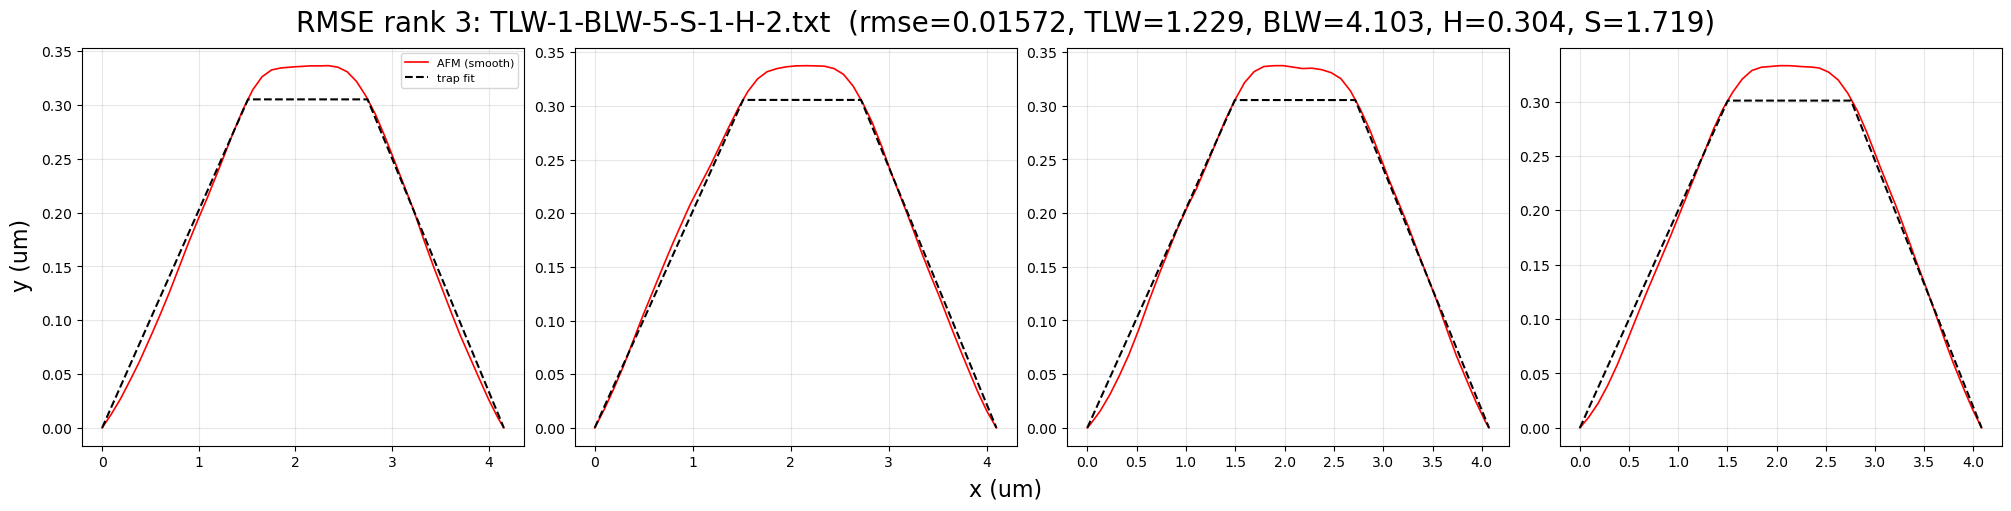

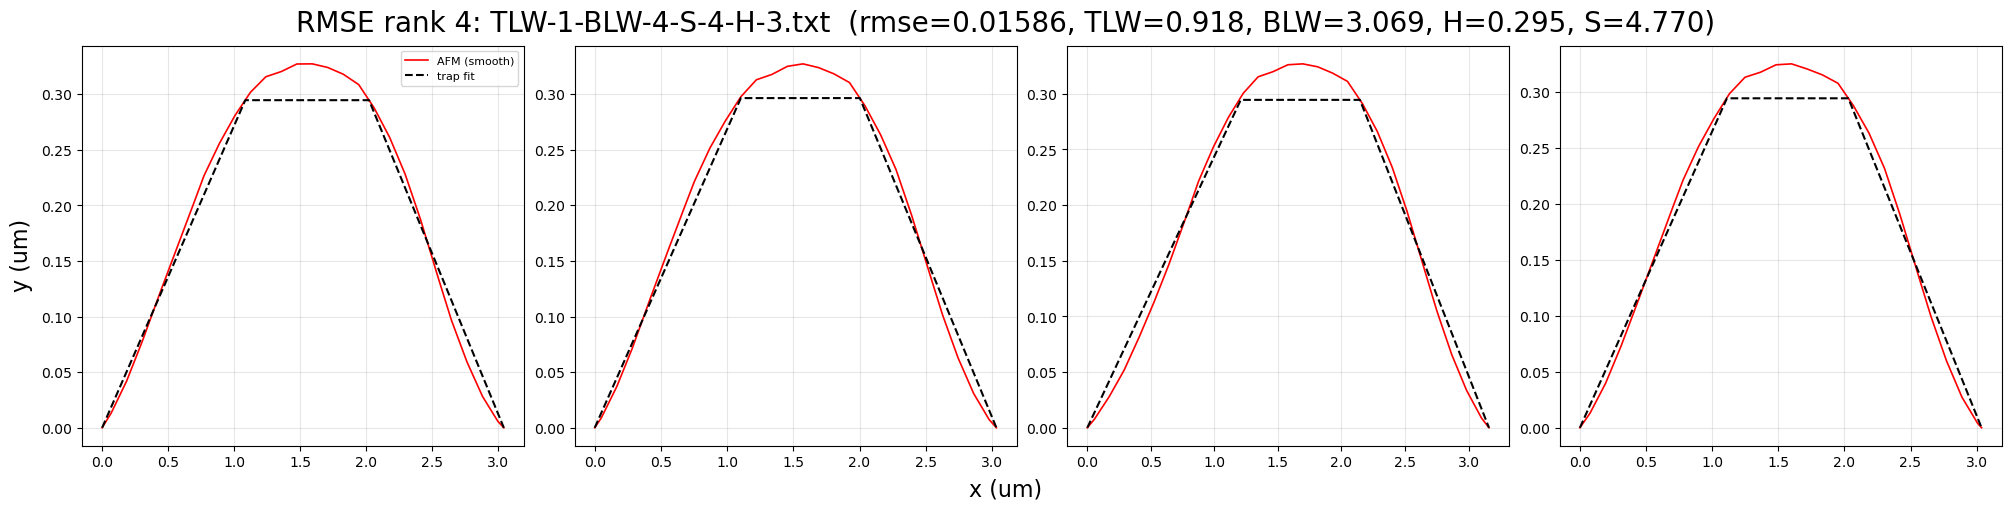

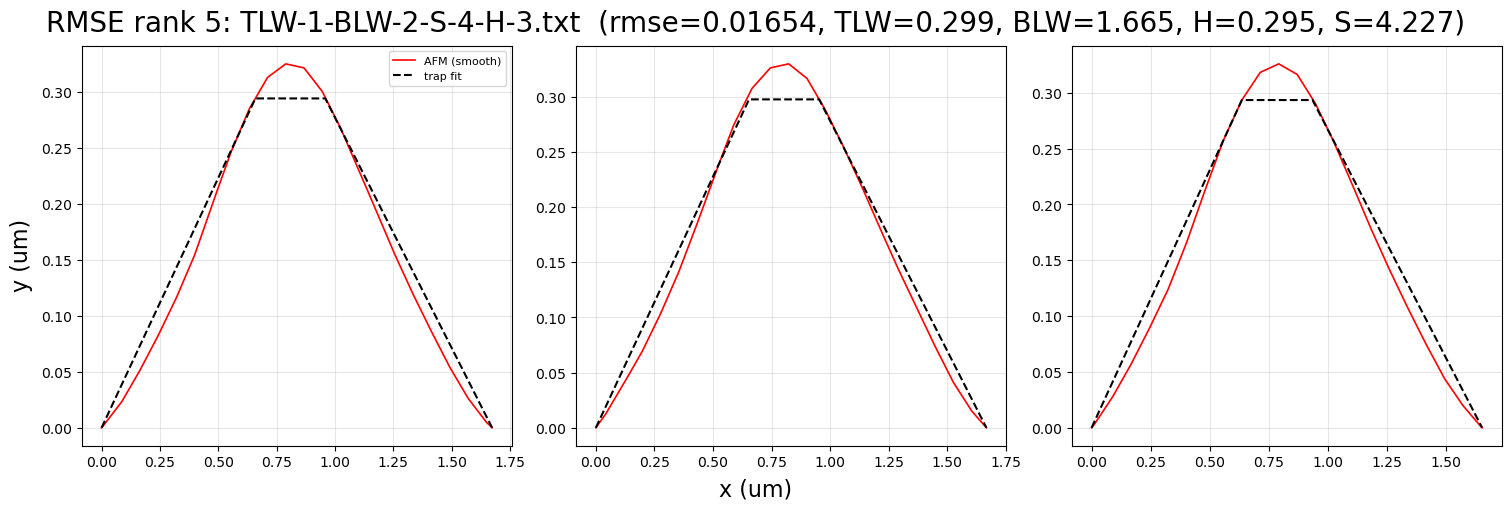


Groove fits in squareness rank order


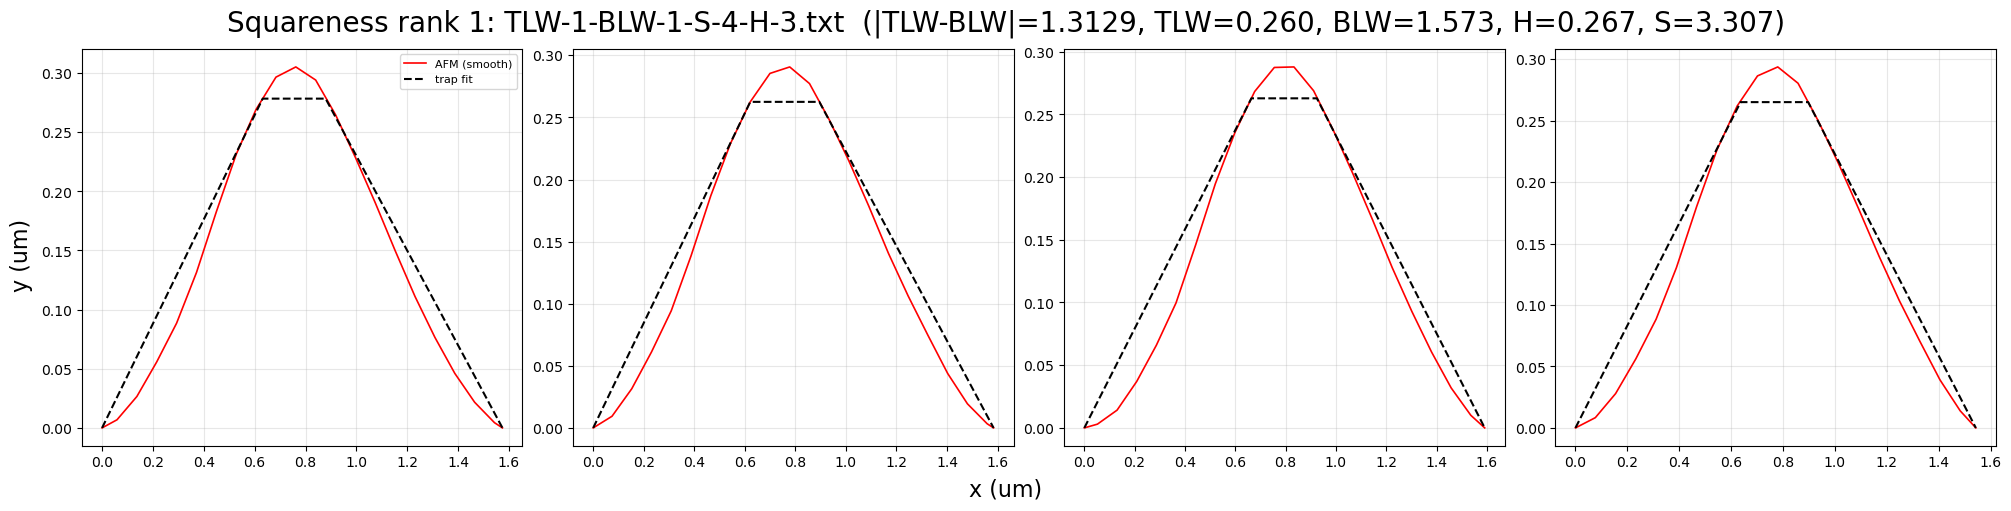

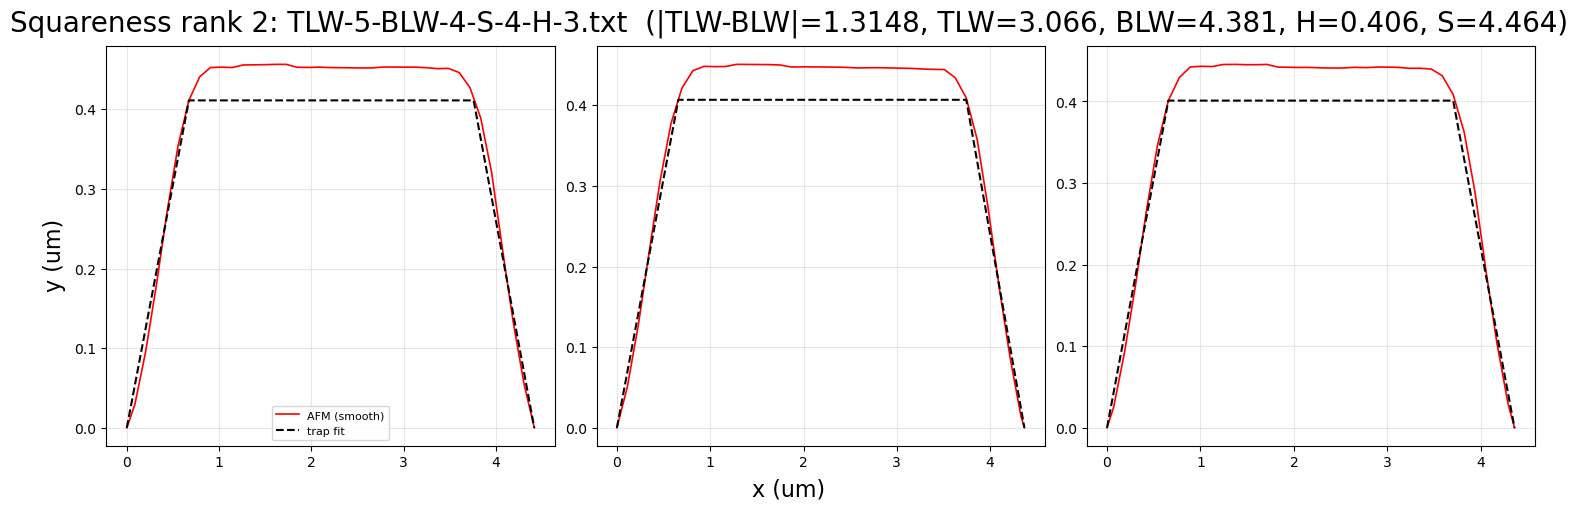

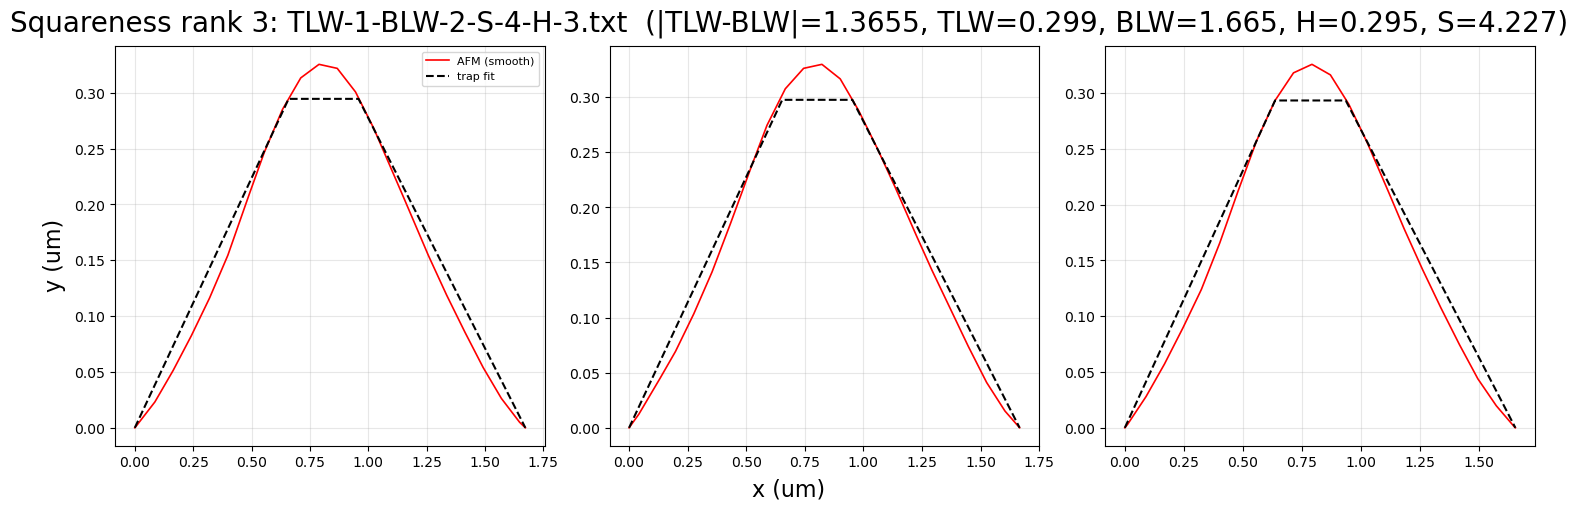

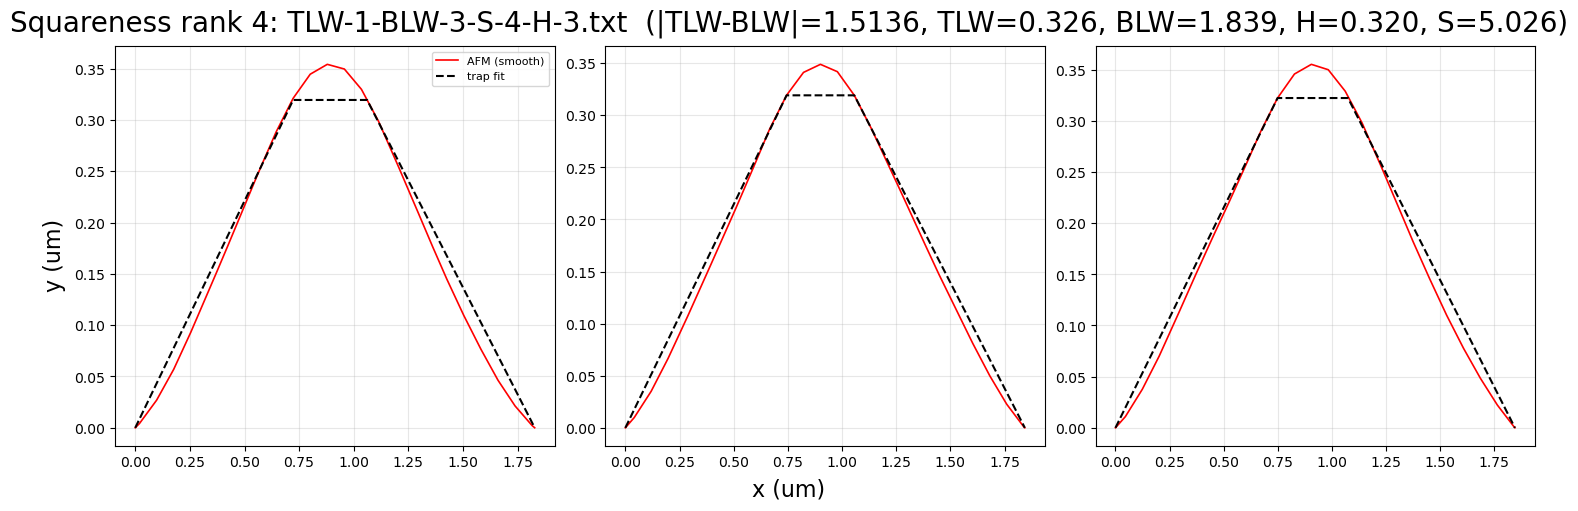

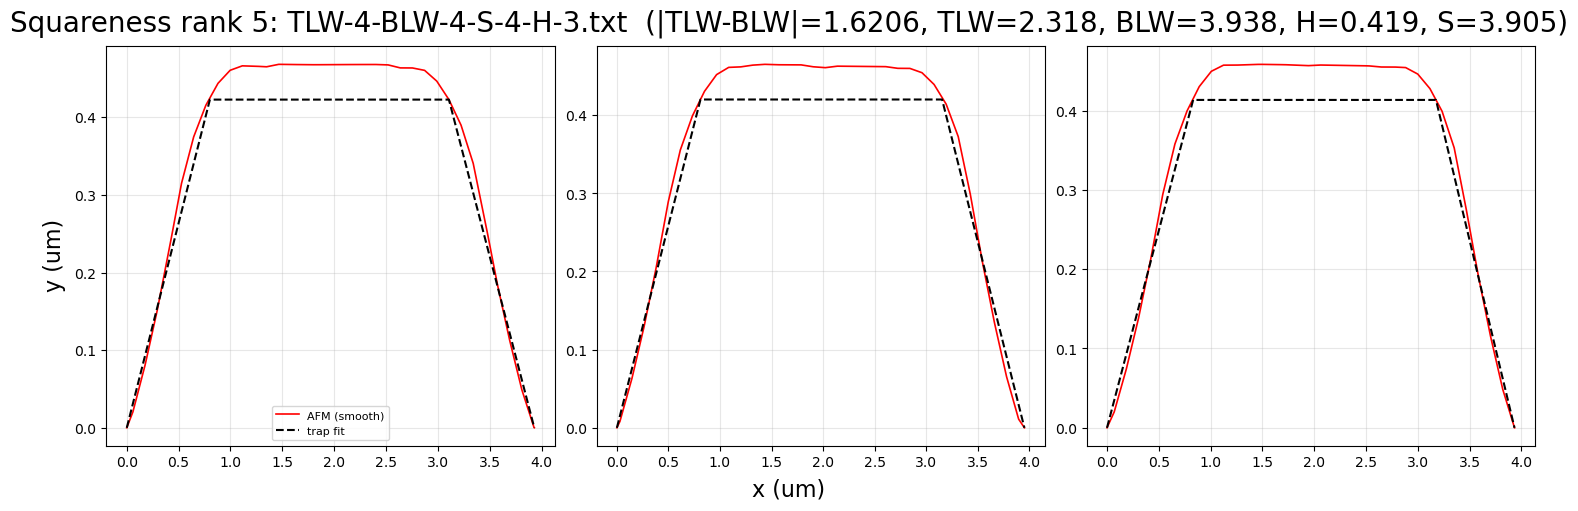


Groove fits in lowest BLW/TLW ratio order


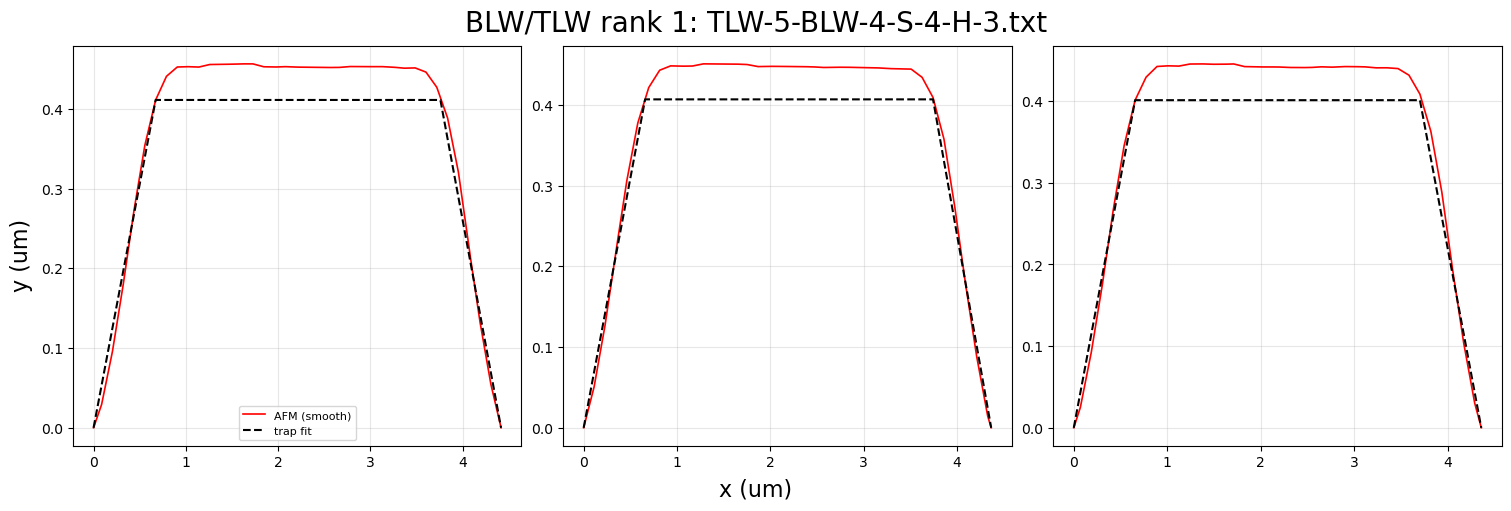

(BLW/TLW=1.4288, TLW=3.066, BLW=4.381, H=0.406, S=4.464)


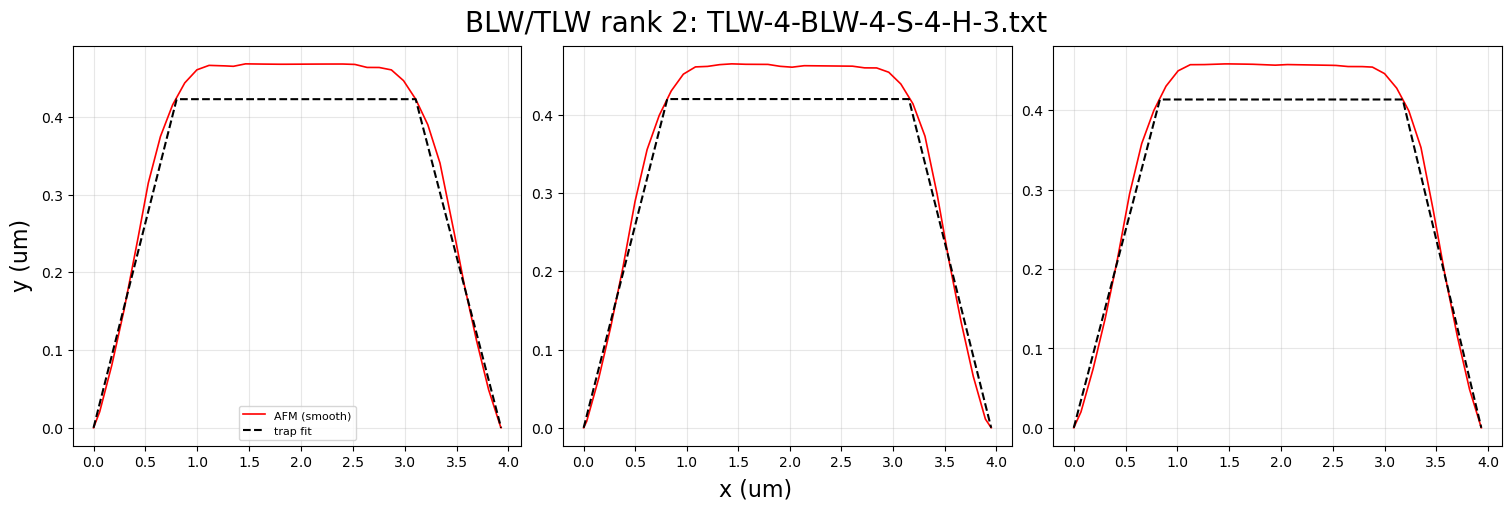

(BLW/TLW=1.6992, TLW=2.318, BLW=3.938, H=0.419, S=3.905)


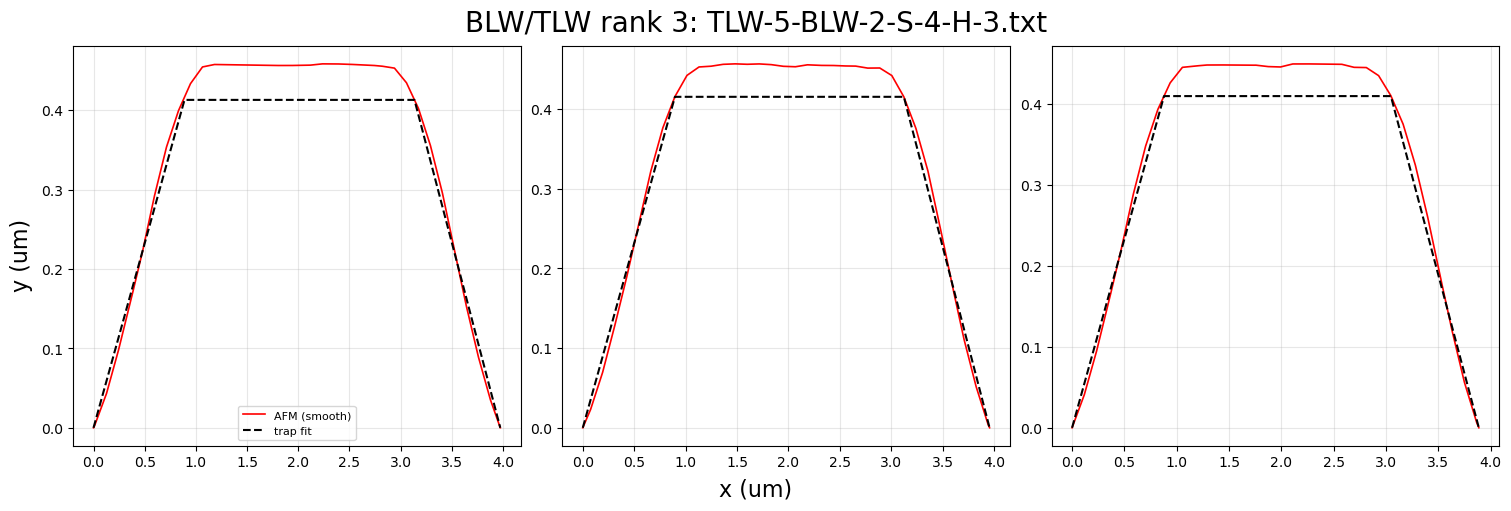

(BLW/TLW=1.7794, TLW=2.214, BLW=3.939, H=0.413, S=4.888)


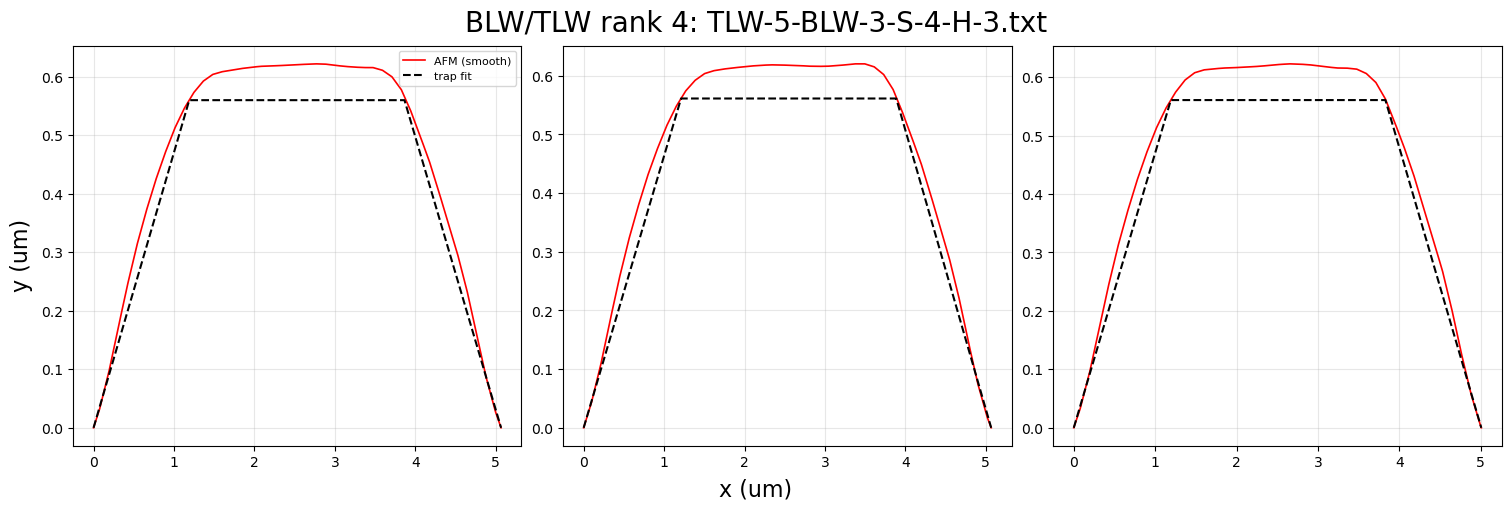

(BLW/TLW=1.8954, TLW=2.663, BLW=5.047, H=0.561, S=3.721)


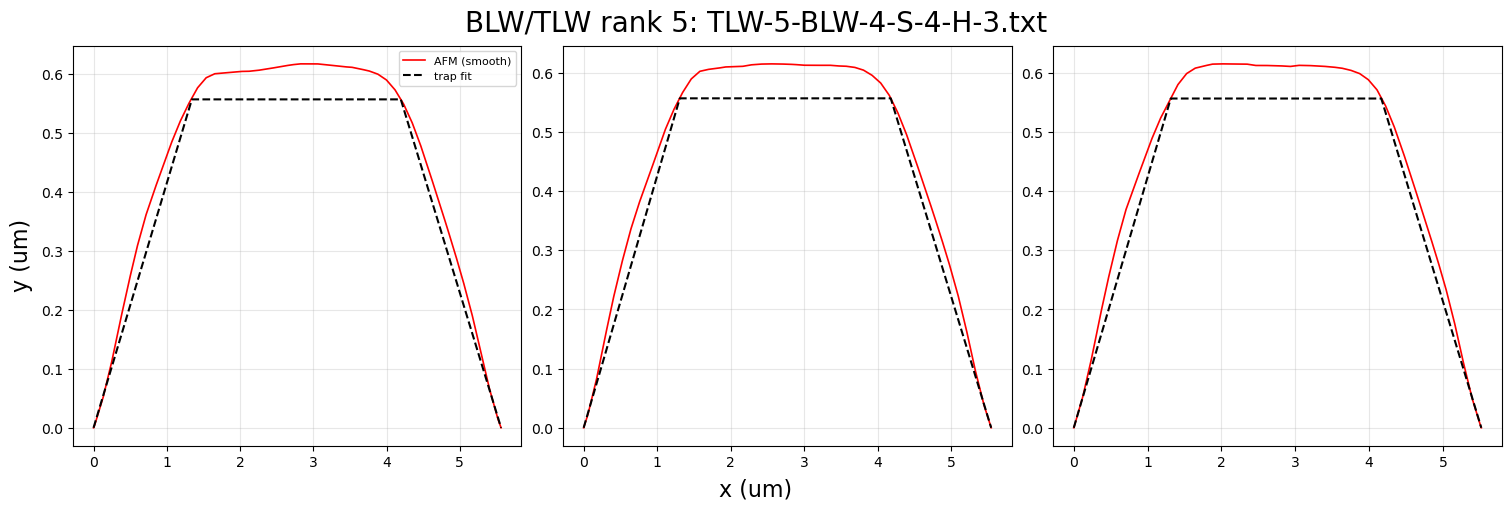

(BLW/TLW=1.9392, TLW=2.858, BLW=5.542, H=0.557, S=3.298)


In [43]:
TOP_N = 5

rows = []
for r in ALL_RECORDS:
    rmse_list = r.get('rmse', [])
    if not rmse_list:
        continue
    rmse_mean = float(np.mean(rmse_list))
    tlw = r.get('sTLW mean', np.nan)
    blw = r.get('sBLW mean', np.nan)
    h = r.get('sH mean', np.nan)
    s = r.get('sS mean', np.nan)
    squareness = abs(tlw - blw) if np.isfinite(tlw) and np.isfinite(blw) else np.nan
    if np.isfinite(tlw) and np.isfinite(blw) and tlw > 0:
        ratio = blw / tlw
    else:
        ratio = np.nan
    rows.append({
        'record': r,
        'file': os.path.basename(r['grating']),
        'sample': r['sample'],
        'rmse_mean': rmse_mean,
        'sTLW_mean': float(tlw),
        'sBLW_mean': float(blw),
        'sH_mean': float(h),
        'sS_mean': float(s),
        'tlw_blw_diff': float(squareness),
        'blw_tlw_ratio': float(ratio),
    })

by_rmse = sorted(rows, key=lambda d: d['rmse_mean'])[:TOP_N]
by_square = sorted(
    [d for d in rows if np.isfinite(d['tlw_blw_diff'])],
    key=lambda d: d['tlw_blw_diff']
)[:TOP_N]
by_ratio = sorted(
    [d for d in rows if np.isfinite(d['blw_tlw_ratio'])],
    key=lambda d: d['blw_tlw_ratio']
)[:TOP_N]

print(f'Top {TOP_N} RMSE (lowest = best fit)')
print('-' * 95)
for rank, d in enumerate(by_rmse, 1):
    print(
        f"  {rank}. {d['file']:<40s}  rmse={d['rmse_mean']:.5f}  "
        f"TLW={d['sTLW_mean']:.3f}  BLW={d['sBLW_mean']:.3f}  ({d['sample']})"
    )

print()
print(f'Top {TOP_N} closest to TLW = BLW (smallest |sTLW - sBLW|)')
print('-' * 95)
for rank, d in enumerate(by_square, 1):
    print(
        f"  {rank}. {d['file']:<40s}  |TLW-BLW|={d['tlw_blw_diff']:.4f}  "
        f"TLW={d['sTLW_mean']:.3f}  BLW={d['sBLW_mean']:.3f}  ({d['sample']})"
    )

print()
print(f'Top {TOP_N} lowest BLW/TLW ratio')
print('-' * 95)
for rank, d in enumerate(by_ratio, 1):
    print(
        f"  {rank}. {d['file']:<40s}  BLW/TLW={d['blw_tlw_ratio']:.4f}  "
        f"TLW={d['sTLW_mean']:.3f}  BLW={d['sBLW_mean']:.3f}  ({d['sample']})"
    )


def plot_record_grooves(record, header):
    grooves = record['grooves smooth']
    fits = record['groove fits']
    rmse = record['rmse']
    n = len(grooves)
    if n == 0:
        print(f'(no grooves) {header}')
        return
    ncols = min(n, 4)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), squeeze=False, layout='constrained')
    axes_flat = axes.flatten()
    for i, ((xs, ys), (xf, yf)) in enumerate(zip(grooves, fits)):
        ax = axes_flat[i]
        ax.plot(xs, ys, color='red', lw=1.2, label='AFM (smooth)')
        ax.plot(xf, yf, color='black', lw=1.5, linestyle='--', label='trap fit')
        ax.grid(alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8)
    for j in range(n, len(axes_flat)):
        axes_flat[j].axis('off')
    fig.suptitle(header, fontsize=20)
    fig.supxlabel('x (um)', fontsize=16)
    fig.supylabel('y (um)', fontsize=16)
    plt.show()


print()
print('=' * 95)
print('Groove fits in RMSE rank order')
print('=' * 95)
for rank, d in enumerate(by_rmse, 1):
    header = (
        f"RMSE rank {rank}: {d['file']}  "
        f"(rmse={d['rmse_mean']:.5f}, TLW={d['sTLW_mean']:.3f}, "
        f"BLW={d['sBLW_mean']:.3f}, H={d['sH_mean']:.3f}, S={d['sS_mean']:.3f})"
    )
    plot_record_grooves(d['record'], header)

print()
print('=' * 95)
print('Groove fits in squareness rank order')
print('=' * 95)
for rank, d in enumerate(by_square, 1):
    header = (
        f"Squareness rank {rank}: {d['file']}  "
        f"(|TLW-BLW|={d['tlw_blw_diff']:.4f}, TLW={d['sTLW_mean']:.3f}, "
        f"BLW={d['sBLW_mean']:.3f}, H={d['sH_mean']:.3f}, S={d['sS_mean']:.3f})"
    )
    plot_record_grooves(d['record'], header)

print()
print('=' * 95)
print('Groove fits in lowest BLW/TLW ratio order')
print('=' * 95)
for rank, d in enumerate(by_ratio, 1):
    header = (
        f"BLW/TLW rank {rank}: {d['file']}"
    )
    plot_record_grooves(d['record'], header)
    print(f"(BLW/TLW={d['blw_tlw_ratio']:.4f}, TLW={d['sTLW_mean']:.3f}, "
        f"BLW={d['sBLW_mean']:.3f}, H={d['sH_mean']:.3f}, S={d['sS_mean']:.3f})")